# Sample Data Analysis Project via Python

## Business Context
You're working with a DTC (Direct-to-Consumer) fitness supplements brand that has been running multichannel marketing campaigns across Facebook, Google, and TikTok. The company currently:
- Spends $1.6M monthly across all channels
- Targets a minimum ROAS of 1.2 (industry benchmark: 1.4)
- Aims to grow revenue by 40% next quarter while maintaining profitability
- Operates in a highly seasonal market with key competitors running major promotions during holiday periods
- Currently underperforming with an overall ROAS of 0.86, well below the target of 1.2

## Challenge
The marketing team needs to optimize their current spend allocation and strategy to improve performance. They face several critical challenges:
- Current ROAS is significantly below target (0.86 vs 1.2)
- Dramatic performance variation across platforms, creatives, and product categories
- Declining efficiency in recent weeks (weekly ROAS trending downward)
- Unclear regional performance patterns
- Uncertain impact of competitive events
- Limited understanding of creative performance and audience targeting effectiveness
- Need to cut spend by 30% in underperforming areas while growing revenue

## Dataset
The provided dataset (Marketing Data) contains 3 months of daily marketing performance data (January-March 2024) with the following structure:
- Date
- Platform (Facebook, Google, TikTok)
- Campaign Name
- Region (West, South, Northeast, Midwest)
- Ad Spend
- CPM
- Impressions
- Frequency
- Clicks
- Purchases
- Revenue
- Product Category (Pre-workout, Protein, Weight Loss, Diet)
- Target Audience (Athletes, Fitness Enthusiasts, Weight Loss)
- Creative Type (Video, Image, Carousel, Search, Display)
- Video Completion Rate
- Customer LTV
- Is_Competitive_Event flag
  
_Note: The dataset contains some reporting inconsistencies and missing values that will need to be addressed._


# Code Begins Here

## Task 1: Data Quality & Exploration
Examine and prepare the dataset for analysis. Your submission should include:

**Primary Deliverable:**
- A data quality assessment summary that documents your data cleaning process and approach
- Clear identification of any data issues and how you addressed them
  
**Key Areas to Address:**
- Data completeness and reliability (identify and handle missing values)
- Performance metric validation and calculation (CTR, CPC, CVR, ROAS)
- Unusual patterns or outliers (identify and address extreme values)
- Key assumptions that could impact recommendations

**Guiding Questions:**
- What data quality issues did you find, and how did you address them?
- Which performance metrics show the most concerning trends?
- What baseline metrics are most relevant for this business given the challenges?
- What preliminary insights can you derive from the data before deeper analysis?
  

### Prep the File for Python

In [423]:
import pandas as pd
import numpy as np

df = pd.read_excel("marketing_data.xlsx")

### Raw Data Peek

In [424]:
df.head(10)

# impressions/comments:
#    - each row contains the details of an ad
#    - "Video_Completion_Rate" seems to only have values if "Creative_Type" is "Video".

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.0,65960,2.75,527,15,1216.74,Protein,Athletes,Video,0.486,772.8,True
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.0,60105,2.51,512,12,868.16,Protein,Athletes,Video,0.486,772.8,True
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.0,36025,2.52,344,9,694.68,Protein,Athletes,Video,0.486,772.8,True
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.0,25743,2.49,272,6,482.66,Protein,Athletes,Video,0.486,772.8,True
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.0,44477,3.10,418,14,852.22,Preworkout,Athletes,Image,NaN,538.2,True
5,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,South,768.14,18.0,42674,2.33,419,11,619.71,Preworkout,Athletes,Image,NaN,538.2,True
6,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,Northeast,833.42,18.0,46301,2.10,425,9,512.75,Preworkout,Athletes,Image,NaN,538.2,True
7,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,Midwest,437.34,18.0,24296,3.44,229,4,218.84,Preworkout,Athletes,Image,NaN,538.2,True
8,2024-01-01,FB,FB_FitnessEnth_Carousel_WeightLoss_001,West,1341.67,18.0,74537,2.61,709,24,1504.39,WeightLoss,FitnessEnth,Carousel,NaN,448.5,True
9,2024-01-01,FB,FB_FitnessEnth_Carousel_WeightLoss_001,South,1933.68,18.0,107426,2.71,906,39,2454.14,WeightLoss,FitnessEnth,Carousel,NaN,448.5,True


### Data Exploration: Info Function

In [425]:
df.info()

# impressions/comments:
#    - almost all of the columns/headers have complete records
#    - "Revenue" column has a few missing records
#    - "Video_Completion_Rate" column has plenty of missing records. This might be due to them only having a value if "Creative_Type" is "Video".
#    - i'll look into the null values in depth

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   3240 non-null   datetime64[ns]
 1   Platform               3240 non-null   object        
 2   Campaign               3240 non-null   object        
 3   Region                 3240 non-null   object        
 4   Spend                  3240 non-null   float64       
 5   CPM                    3240 non-null   float64       
 6   Impressions            3240 non-null   int64         
 7   Frequency              3240 non-null   float64       
 8   Clicks                 3240 non-null   int64         
 9   Purchases              3240 non-null   int64         
 10  Revenue                3220 non-null   float64       
 11  Product_Category       3240 non-null   object        
 12  Target_Audience        3240 non-null   object        
 13  Cre

### Data Exploration: Null Values

In [426]:
df.isna().sum().sort_values(ascending=False)

# impressions/comments:
#    - it seems to be in line with the earlier data exploration using the ".info()" function.
#    - i'll check the "Video_Completion_Rate" to see if it still holds null values when filtering "Creative_Type" to "Video".

Video_Completion_Rate    2012
Revenue                    20
Date                        0
Platform                    0
Campaign                    0
CPM                         0
Impressions                 0
Region                      0
Spend                       0
Clicks                      0
Frequency                   0
Product_Category            0
Purchases                   0
Target_Audience             0
Creative_Type               0
Customer_LTV                0
Is_Competitive_Event        0
dtype: int64

### Raw Data Peek: _Creative_Type_ and _Video_Completion_Rate_

In [427]:
df.loc[df["Creative_Type"] == "Video", ["Creative_Type", "Campaign", "Region", "Video_Completion_Rate"]].head(10)

# impressions/comments:
#    - there still seems to be null values within "Video_Completion_Rate" even if "Creative_Type" is "Video".
#    - it seems to be easily imputable via the "Campaign" mean or mode. It might be that all campaigns use the same video ad, regardless of region.

,Creative_Type,Campaign,Region,Video_Completion_Rate
0,Video,FB_Athletes_Video_Protein_001,West,0.4860
1,Video,FB_Athletes_Video_Protein_001,South,0.4860
2,Video,FB_Athletes_Video_Protein_001,Northeast,0.4860
3,Video,FB_Athletes_Video_Protein_001,Midwest,0.4860
24,Video,TT_Athletes_Video_Protein_001,West,0.7410
25,Video,TT_Athletes_Video_Protein_001,South,NaN
26,Video,TT_Athletes_Video_Protein_001,Northeast,0.7410
27,Video,TT_Athletes_Video_Protein_001,Midwest,0.7410
28,Video,TT_FitnessEnth_Video_Preworkout_001,West,NaN
29,Video,TT_FitnessEnth_Video_Preworkout_001,South,0.6793


### Data Exploration: Video_Completion_Rate

In [428]:
df.loc[df["Creative_Type"] == "Video", ["Creative_Type", "Video_Completion_Rate"]].isna().sum().sort_values(ascending=False)

# impressions/comments:
#    - this confirms a missing data issue between "Creative_Type" and "Video_Completion_Rate".

Video_Completion_Rate    212
Creative_Type              0
dtype: int64

### Data Exploration: Describe Function

In [429]:
df.describe()

# impressions/comments:
#    - the "Impressions", "Clicks",and "Purchases" columns have records of value 0. I'll have to look into this in depth.
#    - massive expenditure problem, with the max "Spend" value going nearly 100 times over the median, and the standard deviation going above twice the mean.

,Date,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Video_Completion_Rate,Customer_LTV
count,3240,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3240.000000,3220.000000,1228.000000,3240.000000
mean,2024-02-14 12:00:00.000000256,1495.577633,14.223593,100056.933951,3.008373,687.963889,19.274383,1295.612522,0.574998,538.660000
min,2024-01-01 00:00:00,326.510000,10.010000,0.000000,2.010000,0.000000,0.000000,113.600000,0.399500,252.720000
25%,2024-01-23 00:00:00,981.400000,12.160000,63965.000000,2.490000,409.000000,10.000000,646.855000,0.486000,393.120000
50%,2024-02-14 12:00:00,1261.495000,14.180000,88889.500000,2.850000,611.000000,16.000000,1065.850000,0.589600,538.200000
75%,2024-03-08 00:00:00,1659.267500,15.760000,126429.500000,3.362500,880.000000,24.000000,1708.735000,0.646300,604.800000
max,2024-03-30 00:00:00,119315.000000,23.850000,365425.000000,7.780000,2866.000000,107.000000,6987.780000,0.741000,940.800000
std,NaN,3727.564711,2.989872,50143.396744,0.702799,413.818091,13.797493,882.101461,0.092451,202.036512


### Data Validation: _Impressions_, _Clicks_, and _Purchases_

In [430]:
print((df["Impressions"]==0).sum())
print((df["Clicks"]==0).sum())
print((df["Purchases"]==0).sum())

# impressions/comments:
#    - this reoccurring "47" value seems to imply that these three columns are closely related.
#    - since "Impressions" is the instance of an ad, it must be the precursor variable for "Clicks" and "Purchases".
#    - similarly, "Clicks" must be the precursor to "Purchases", as one must click on an ad before a purchase could be tracked.
#    - i'll check if these 0 values all belong in the same records.

47
147
47


### Raw Data Peek: _Impressions_, _Clicks_, and _Purchases_

In [431]:
df.loc[df["Impressions"] == 0, ["Impressions", "Clicks", "Purchases"]].reset_index().tail()

# impressions/comments:
#    - this confirms a data quality issue between the three closely related columns, as they all belong in the same set of records.
#    - we can further infer that the other 100 "Clicks" with 0 values have non-zero "Impressions", and are simply ads that did not get any clicks.

,index,Impressions,Clicks,Purchases
42,2851,0,0,0
43,2867,0,0,0
44,2967,0,0,0
45,3015,0,0,0
46,3147,0,0,0


### Task 1 Summary

- Explored the dataset using various techniques and methods to understand the distribution of key metrics, mainly "Impressions", "Clicks", "Purchases", and "Spend".
- Noted data quality concerns, including:
  - Presence of records with zero values in "Impressions", "Clicks", and "Purchases".
  - Significant outliers in "Spend", with maximum values far exceeding the median and mean.
- Investigated the relationship between "Impressions", "Clicks", and "Purchases":
  - Counted the number of zero-value records in each column.
  - Assumed that "Impressions" is a precursor to "Clicks" and "Purchases", i.e., clicks and purchases cannot occur without impressions.
- Checked if zero values in these columns co-occur in the same records:
  - Filtered and reviewed records where "Impressions" is zero.
  - Confirmed that records with zero "Impressions" also have zero "Clicks" and "Purchases", indicating a data quality issue.
  - Inferred that records with zero "Clicks" but nonzero "Impressions" represent ads that did not receive any clicks, which is expected behavior.
- **Assumptions made:**
  - "Impressions" must be greater than zero for "Clicks" or "Purchases" to occur.
  - Zero values in all three columns for the same record may indicate missing or invalid data rather than true campaign performance.
- **Possible solutions to address for Task 1.5:**
  - Remove or flag records where "Impressions", "Clicks", and "Purchases" are all zero, as they may not represent valid ad activity.
  - Investigate the data ingestion or ETL process to determine why such records exist and whether they can be prevented upstream.
  - Consider imputing or correcting these records if additional context is available, or exclude them from downstream analysis to avoid skewing results.

## Task 1.5: Data Wrangling and Transformation

### Dropping "Impossible" Records

In [432]:
df_final = df.copy()

# Drop records where "Clicks" are 0, but "Purchases" are non-zero
df_final = df_final[~((df_final["Clicks"] == 0) & (df_final["Purchases"] > 0))]

# Drop records where "Impressions" are 0, but "Clicks" are non-zero
df_final = df_final[~((df_final["Impressions"] == 0) & (df_final["Clicks"] > 0))]

# Drop records where "Impressions" are 0
df_final = df_final[df_final["Impressions"] != 0]

### Dropping Records with Missing _Revenue_ Values

Approach 1 - Drop due to MCAR data: The revenue was simply not logged by the pipeline due to a tracking error.

Approach 2 - Impute via mean: The Revenue data must be normally distributed, in order to minimize bias. Otherwise, drop.

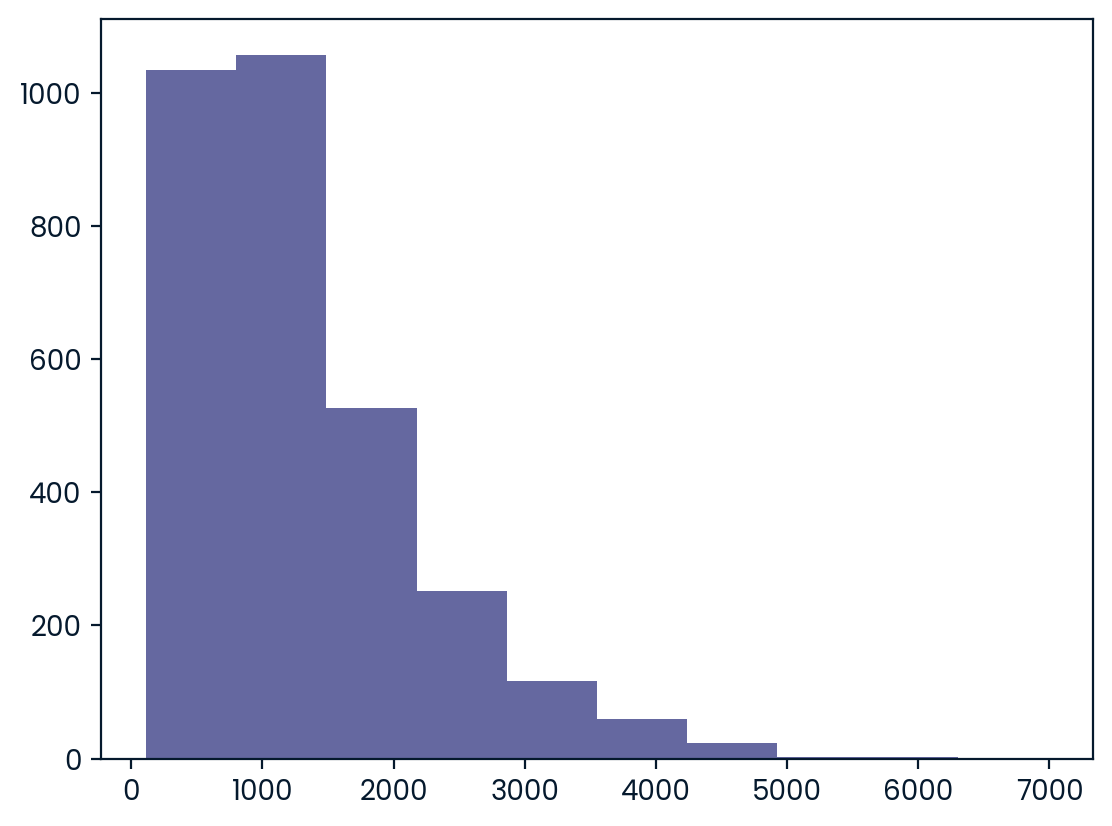

In [433]:
import matplotlib.pyplot as plt

plt.hist(df_final["Revenue"])
plt.show()

# The result is to drop the "Revenue" records with missing values all the same.
df_final = df_final.dropna(subset=["Revenue"])

### Imputing missing _Video_Completion_Rate_ Values

In [434]:
# Impute missing "Video_Completion_Rate" by "Campaign" mean, only for "Creative_Type" == "Video"
df_final["Video_Completion_Rate"] = df_final.groupby("Campaign")["Video_Completion_Rate"].transform(
    lambda x: x.fillna(x.mean())
).where(df_final["Creative_Type"] == "Video", df_final["Video_Completion_Rate"])

Appending the Calculated Fields _CTR_, _CPC_, _CVR_, and _ROAS_

In [435]:
df_final["CTR"] = df_final["Clicks"] / df_final["Impressions"]
df_final["CPC"] = df_final["Spend"] / df_final["Clicks"]
df_final["CVR"] = df_final["Purchases"] / df_final["Clicks"]
df_final["ROAS"] = df_final["Revenue"] / df_final["Spend"]

### Final Data Exploration Check

In [436]:
df_final.describe()

,Date,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Video_Completion_Rate,Customer_LTV,CTR,CPC,CVR,ROAS
count,3074,3074.000000,3074.000000,3074.000000,3074.000000,3074.000000,3074.000000,3074.000000,1416.000000,3074.000000,3074.000000,3074.000000,3074.000000,3074.000000
mean,2024-02-14 07:32:02.966818560,1517.038025,14.110641,102836.842550,3.009005,721.939493,19.648992,1306.142215,0.574745,533.638887,0.007579,2.635812,0.026541,0.955401
min,2024-01-01 00:00:00,326.510000,10.010000,18026.000000,2.010000,78.000000,2.000000,113.600000,0.399500,252.720000,0.001848,0.735908,0.007426,0.001554
25%,2024-01-23 00:00:00,993.345000,12.140000,65908.500000,2.490000,436.000000,10.000000,653.340000,0.508500,393.120000,0.005015,1.461371,0.021079,0.552583
50%,2024-02-14 00:00:00,1275.900000,13.000000,91395.000000,2.850000,633.000000,16.000000,1074.800000,0.588200,538.200000,0.006709,1.995012,0.026380,0.840201
75%,2024-03-08 00:00:00,1678.327500,15.660000,129027.500000,3.370000,900.000000,24.000000,1717.497500,0.643900,604.800000,0.008933,2.726049,0.031599,1.235157
max,2024-03-30 00:00:00,119315.000000,23.850000,365425.000000,7.780000,2866.000000,107.000000,6987.780000,0.741000,940.800000,0.023394,555.806897,0.060729,4.627785
std,NaN,3824.480156,2.957063,49142.677218,0.698821,394.966744,13.730333,883.365413,0.090732,199.929835,0.003678,11.787212,0.008092,0.538520


### Final Raw Data Peek

In [437]:
df_final.head(10)

,Date,Platform,Campaign,Region,Spend,CPM,Impressions,Frequency,Clicks,Purchases,Revenue,Product_Category,Target_Audience,Creative_Type,Video_Completion_Rate,Customer_LTV,Is_Competitive_Event,CTR,CPC,CVR,ROAS
0,2024-01-01,FB,FB_Athletes_Video_Protein_001,West,1187.29,18.0,65960,2.75,527,15,1216.74,Protein,Athletes,Video,0.486,772.8,True,0.007990,2.252922,0.028463,1.024804
1,2024-01-01,FB,FB_Athletes_Video_Protein_001,South,1081.89,18.0,60105,2.51,512,12,868.16,Protein,Athletes,Video,0.486,772.8,True,0.008518,2.113066,0.023438,0.802448
2,2024-01-01,FB,FB_Athletes_Video_Protein_001,Northeast,648.47,18.0,36025,2.52,344,9,694.68,Protein,Athletes,Video,0.486,772.8,True,0.009549,1.885087,0.026163,1.071260
3,2024-01-01,FB,FB_Athletes_Video_Protein_001,Midwest,463.38,18.0,25743,2.49,272,6,482.66,Protein,Athletes,Video,0.486,772.8,True,0.010566,1.703603,0.022059,1.041607
4,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,West,800.59,18.0,44477,3.10,418,14,852.22,Preworkout,Athletes,Image,NaN,538.2,True,0.009398,1.915287,0.033493,1.064490
5,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,South,768.14,18.0,42674,2.33,419,11,619.71,Preworkout,Athletes,Image,NaN,538.2,True,0.009819,1.833270,0.026253,0.806767
6,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,Northeast,833.42,18.0,46301,2.10,425,9,512.75,Preworkout,Athletes,Image,NaN,538.2,True,0.009179,1.960988,0.021176,0.615236
7,2024-01-01,FB,FB_Athletes_Image_Preworkout_002,Midwest,437.34,18.0,24296,3.44,229,4,218.84,Preworkout,Athletes,Image,NaN,538.2,True,0.009425,1.909782,0.017467,0.500389
8,2024-01-01,FB,FB_FitnessEnth_Carousel_WeightLoss_001,West,1341.67,18.0,74537,2.61,709,24,1504.39,WeightLoss,FitnessEnth,Carousel,NaN,448.5,True,0.009512,1.892341,0.033850,1.121282
9,2024-01-01,FB,FB_FitnessEnth_Carousel_WeightLoss_001,South,1933.68,18.0,107426,2.71,906,39,2454.14,WeightLoss,FitnessEnth,Carousel,NaN,448.5,True,0.008434,2.134305,0.043046,1.269155


### Task 1.5 Summary

- Removed records where "Clicks" were 0 but "Purchases" were non-zero, and where "Impressions" were 0 but "Clicks" were non-zero, to ensure logical consistency in the data.
- Dropped all records with zero "Impressions" to focus analysis on meaningful ad exposures.
- Removed records with missing "Revenue" values to ensure analyses are based on complete financial data.
- Imputed missing "Video_Completion_Rate" values using the mean per "Campaign", but only for rows where "Creative_Type" is "Video".
- Performed a final data exploration check using `df_final.describe()` to review summary statistics and confirm data integrity after cleaning and imputation steps.
- Produced a cleaned and imputed dataset (`df_final`) ready for further analysis in subsequent tasks.
- Added the calculated fields "CTR", "CPC", "CVR", and "ROAS" as a final step.

## Task 2: Performance Analysis
Conduct a comprehensive analysis to identify performance patterns and opportunities:

**Required Analyses:**
- Channel performance analysis with statistical significance testing
    - Compare platforms (Facebook, Google, TikTok) across key metrics
    - Identify which platform is driving the most value and why
- Regional performance comparison
    - Analyze regional differences with statistical significance testing
    - Identify over/underperforming regions and potential reasons
- Creative performance analysis
    - Compare creative types (Video, Image, Carousel, Search, Display)
    - Analyze the relationship between video completion rate and conversion
- Product category and audience targeting performance
    - Identify which products and audience segments deliver the best ROAS
- Week-over-week trend analysis to identify performance patterns
- Impact of competitive events on key metrics
- Relationship between ad frequency and conversion rates
  
**Deliverable:**
- Technical analysis document with:
  - Clearly documented methodology for each analysis
  - Statistical tests and significance levels used
  - Visualizations highlighting key findings
  - Interpretations of findings in business context
    

### Normality Testing: _ROAS_ by _Platform_

H0: The data are normally distributed.

HA: The data are not normally distributed.

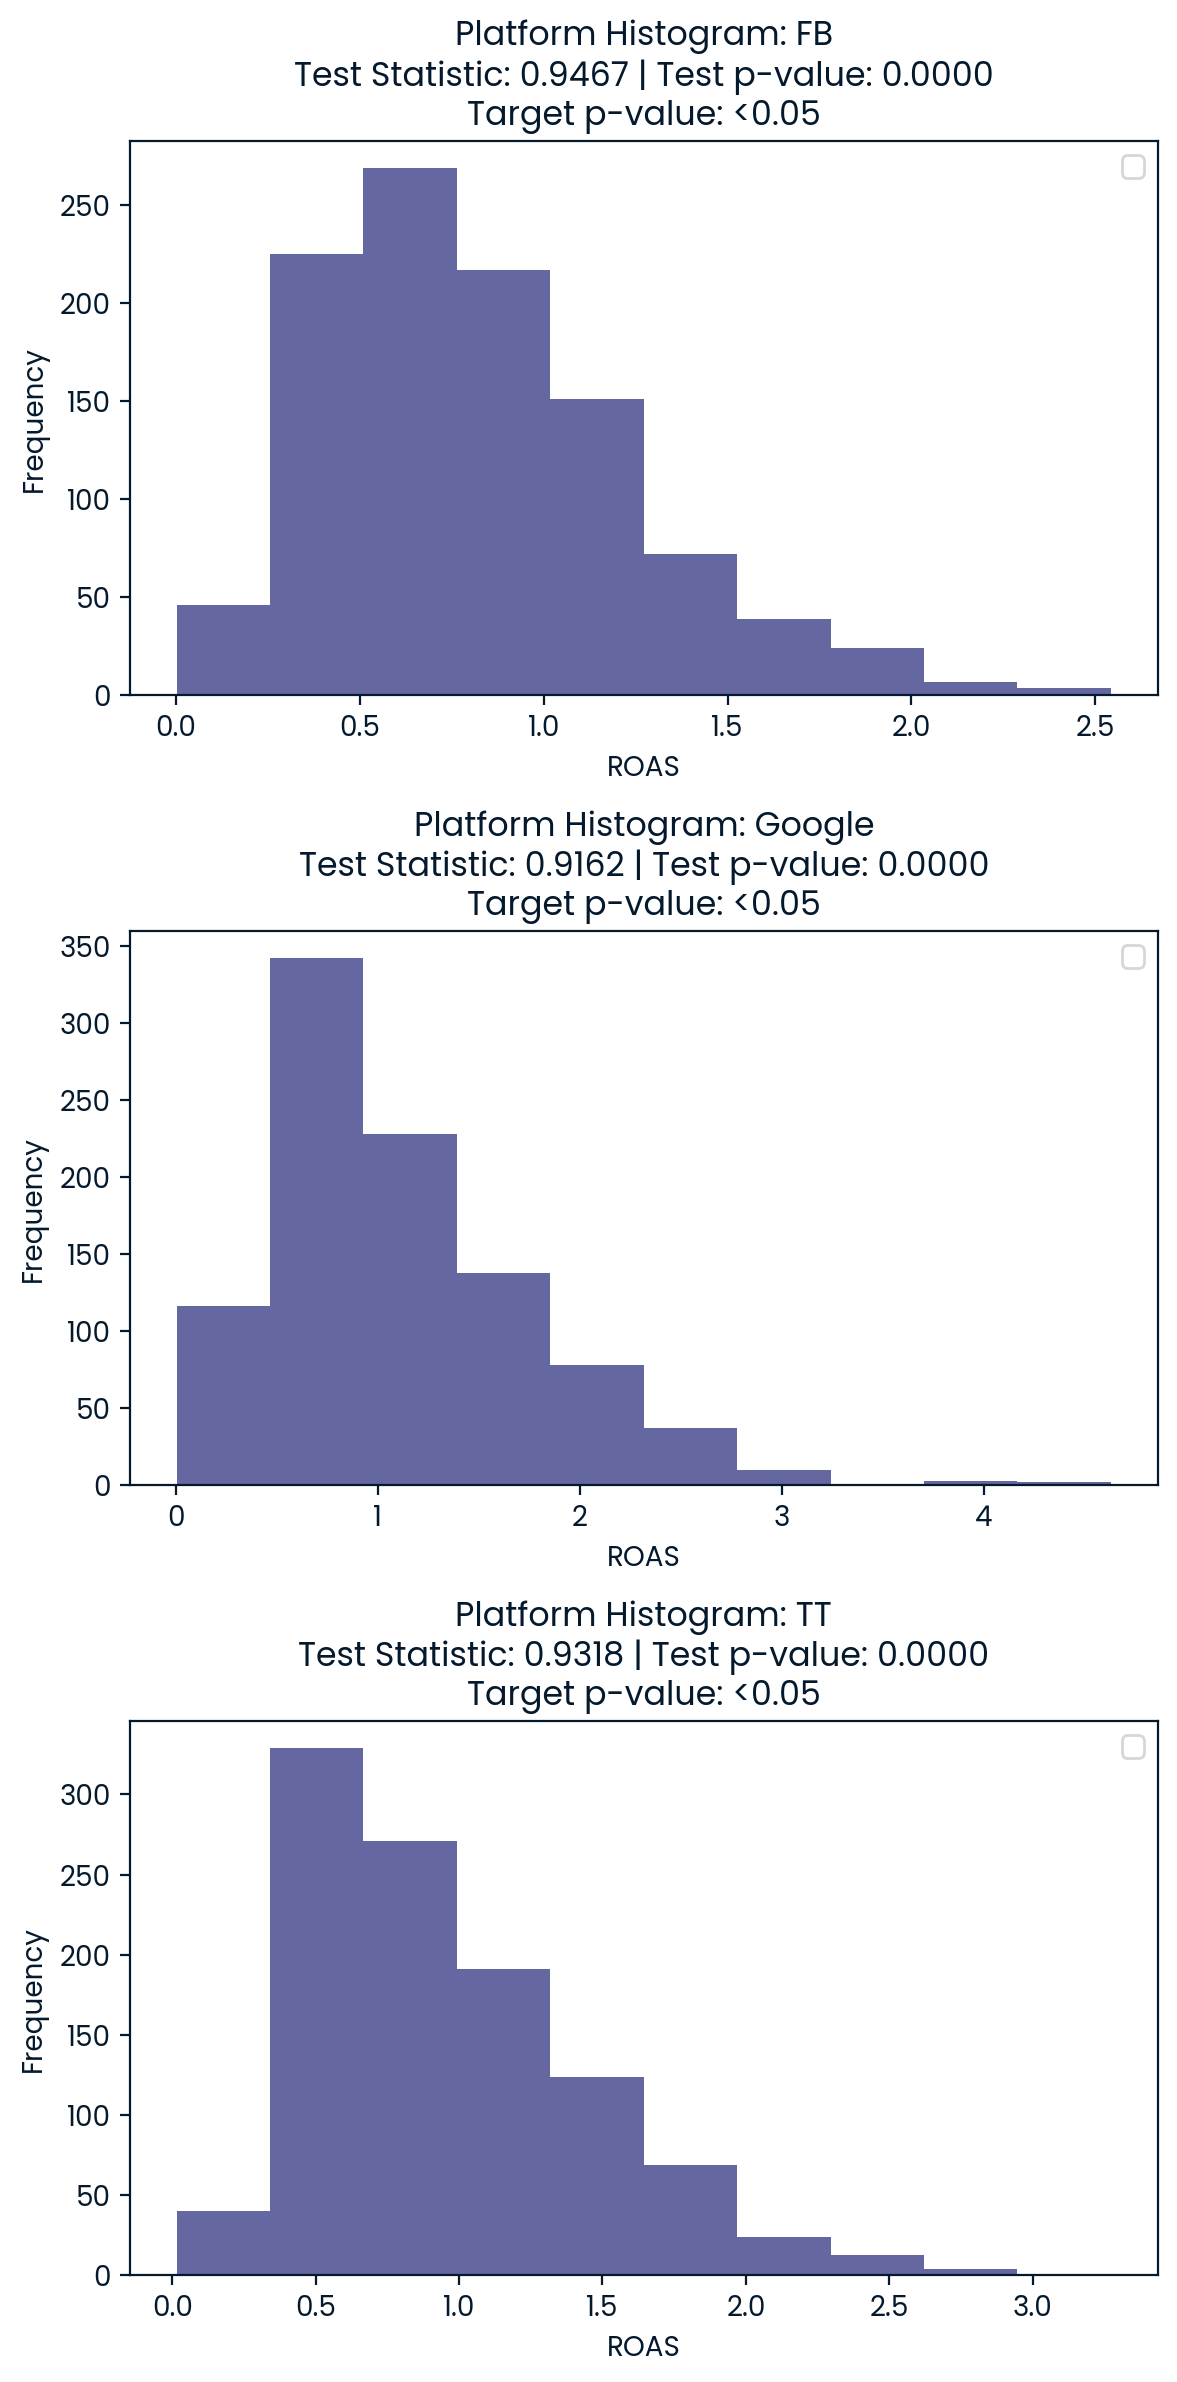

In [438]:
from scipy.stats import shapiro

def shapiro_wilk_normality_test(group, metric):
    subgroups_name = df_final[group].unique()
    subgroups = [df_final[df_final[group] == subgroup][metric].dropna() for subgroup in subgroups_name]

    fig, axes = plt.subplots(len(subgroups), 1, figsize=(6, 4 * len(subgroups)))
    if len(subgroups) == 1:
        axes = [axes]  # Ensure axes is iterable

    for ax, subgroup_name, subgroup in zip(axes, subgroups_name, subgroups):
        stat, p = shapiro(subgroup)
        ax.hist(subgroup)
        ax.set_title(f"Platform Histogram: {subgroup_name}\nTest Statistic: {stat:.4f} | Test p-value: {p:.4f}\nTarget p-value: <0.05")
        ax.set_xlabel(metric)
        ax.set_ylabel("Frequency")
        ax.legend()

    plt.tight_layout()
    plt.show()

shapiro_wilk_normality_test("Platform", "ROAS")

# impressions/comments:
#    - because each of the actual p-value is less than the target p-value, then we reject the null hypothesis for all platform groups.
#    - because the data is not normally distributed, we cannot use the ANOVA test. Instead, we will use the Kruskal-Wallis test.

### Channel Performance Analysis: Kruskal-Wallis Test

H0: The median ROAS rates across the three groups are equal.

HA: The median ROAS rates across the three groups are not equal.

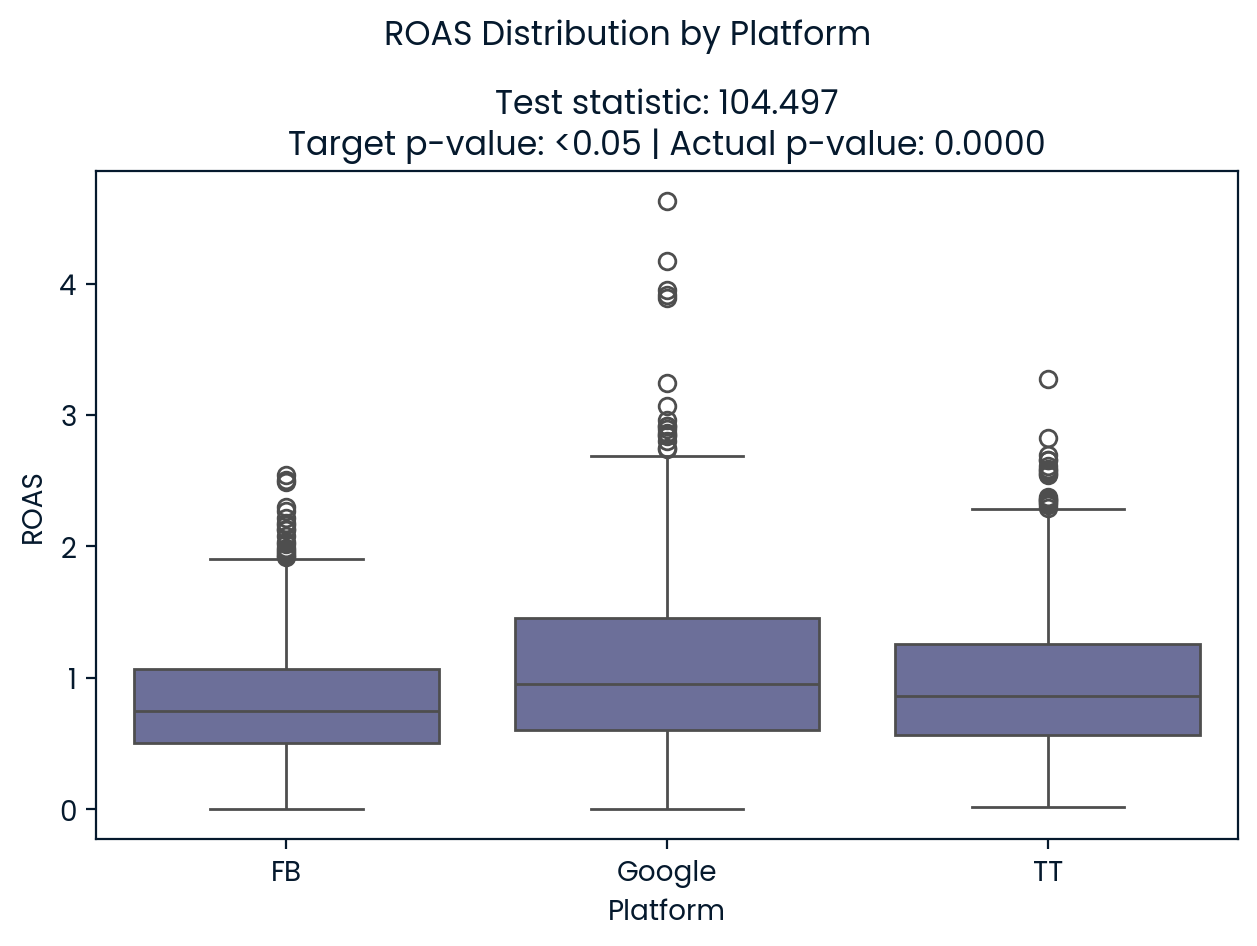

In [439]:
from scipy.stats import kruskal
import matplotlib.pyplot as plt
import seaborn as sns

def kruskal_wallis_significance_test(group, metric):
    subgroups_name = df_final[group].unique()
    subgroups = [df_final[df_final[group] == subgroup][metric].dropna() for subgroup in subgroups_name]

    kruskal_stat, kruskal_p = kruskal(*subgroups)
    
    sns.boxplot(x=group, y=metric, data=df_final)
    plt.suptitle(f"ROAS Distribution by {group}")
    plt.title(f'Test statistic: {kruskal_stat:.3f}\nTarget p-value: <0.05 | Actual p-value: {kruskal_p:.4f}')
    plt.ylabel(metric)
    plt.xlabel(group)
    plt.tight_layout()
    plt.show()

kruskal_wallis_significance_test("Platform", "ROAS")

# impressions/comments:
#    - because the actual p-value is less than the target p-value, then we reject the null hypothesis.
#    - from the box plot, it seems that Google is driving the most value for ads, but we can make a post-hoc test to be certain.

### Channel Performance Analysis: Post-Hoc Test (Dunn's)

In [440]:
import scikit_posthocs as sp

dunn_results = sp.posthoc_dunn(df_final, val_col='ROAS', group_col='Platform', p_adjust='bonferroni')
dunn_results

# impressions/comments:
#    - all the groups indeed differ from each other. To compound our earlier results from the boxplot, Google outranks the rest as the main driving force for ads.

,FB,Google,TT
FB,1.000000e+00,1.444833e-23,1.298716e-09
Google,1.444833e-23,1.000000e+00,1.490047e-04
TT,1.298716e-09,1.490047e-04,1.000000e+00


### Normality Testing: ROAS by Region

H0: The data are normally distributed.

HA: The data are not normally distributed.

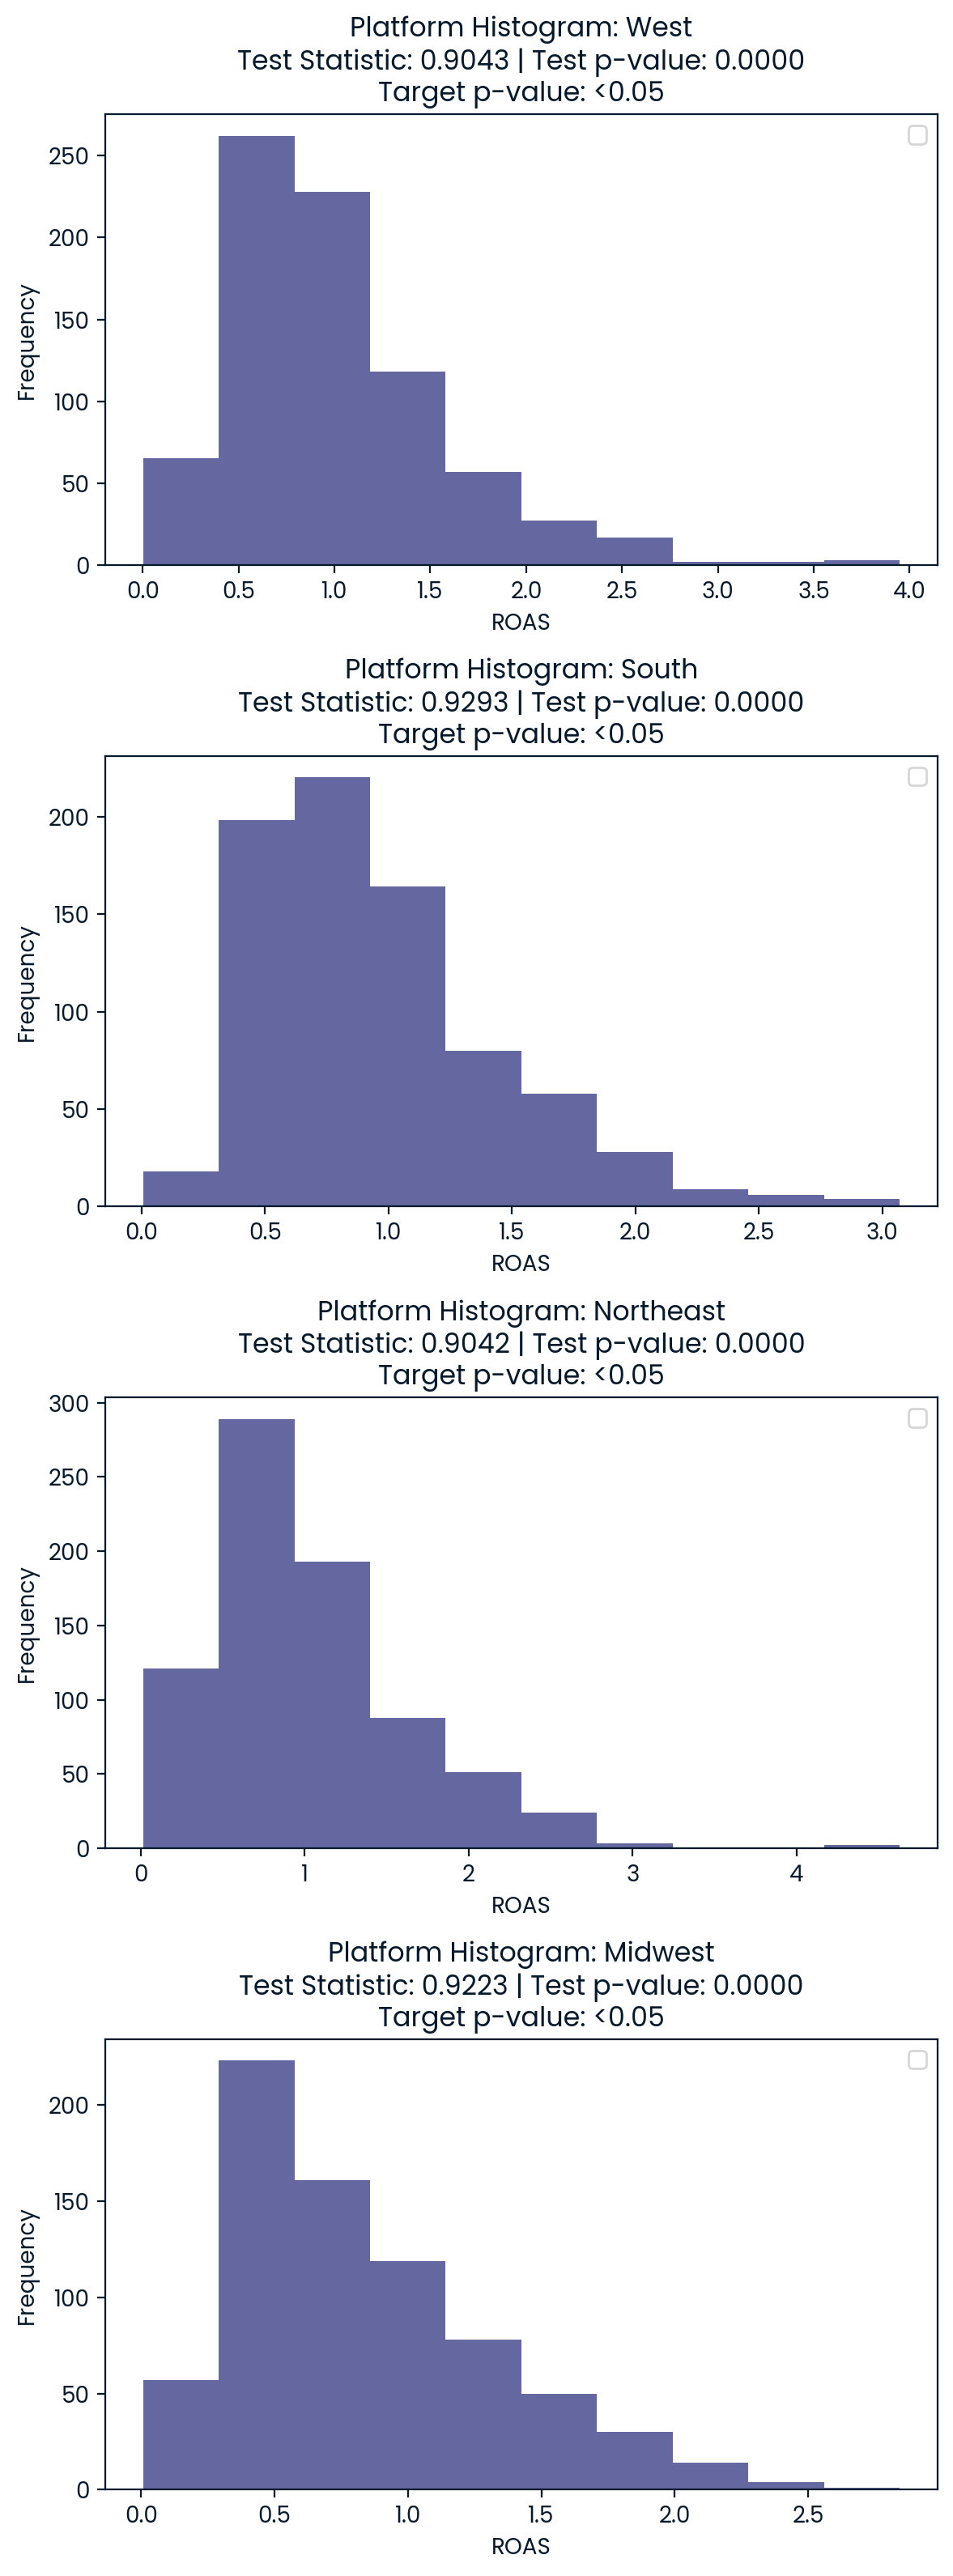

In [441]:
shapiro_wilk_normality_test("Region", "ROAS") # from the function already created

# impressions/comments:
#    - because each of the actual p-value is less than the target p-value, then we reject the null hypothesis for all platform groups.
#    - because the data is not normally distributed, we cannot use the ANOVA test. Instead, we will use the Kruskal-Wallis test.

### Regional Performance Comparison: Kruskal-Wallis Test

H0: The median ROAS rates across the four groups are equal.

HA: The median ROAS rates across the four groups are not equal.

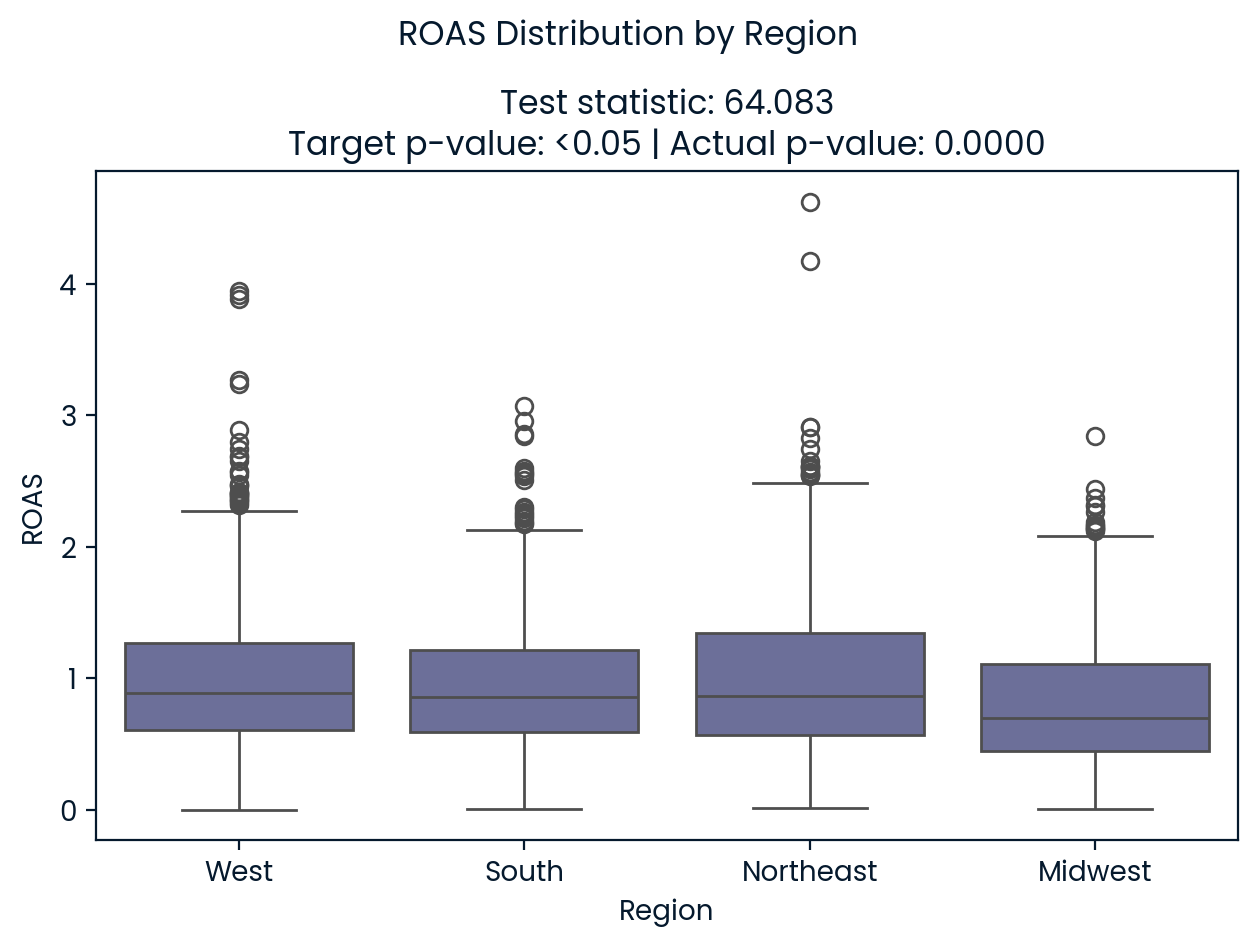

In [442]:
kruskal_wallis_significance_test("Region", "ROAS") # from the function already created

# impressions/comments:
#    - because the actual p-value is less than the target p-value, then we reject the null hypothesis.
#    - from the box plot, it seems that the Midwest is driving the least value for ads, but we can make a post-hoc test to be certain.

### Regional Performance Comparison: Post-Hoc Test (Dunn's)

In [443]:
dunn_results = sp.posthoc_dunn(df_final, val_col='ROAS', group_col='Region', p_adjust='bonferroni')
print(dunn_results)

# impressions/comments:
#    - Compounding the results from the boxplot, only the Midwest is significantly different, while the others have similar driving performance.

                Midwest     Northeast         South          West
Midwest    1.000000e+00  3.134084e-11  2.031399e-08  8.869655e-11
Northeast  3.134084e-11  1.000000e+00  1.000000e+00  1.000000e+00
South      2.031399e-08  1.000000e+00  1.000000e+00  1.000000e+00
West       8.869655e-11  1.000000e+00  1.000000e+00  1.000000e+00


### Creative Performance Analysis

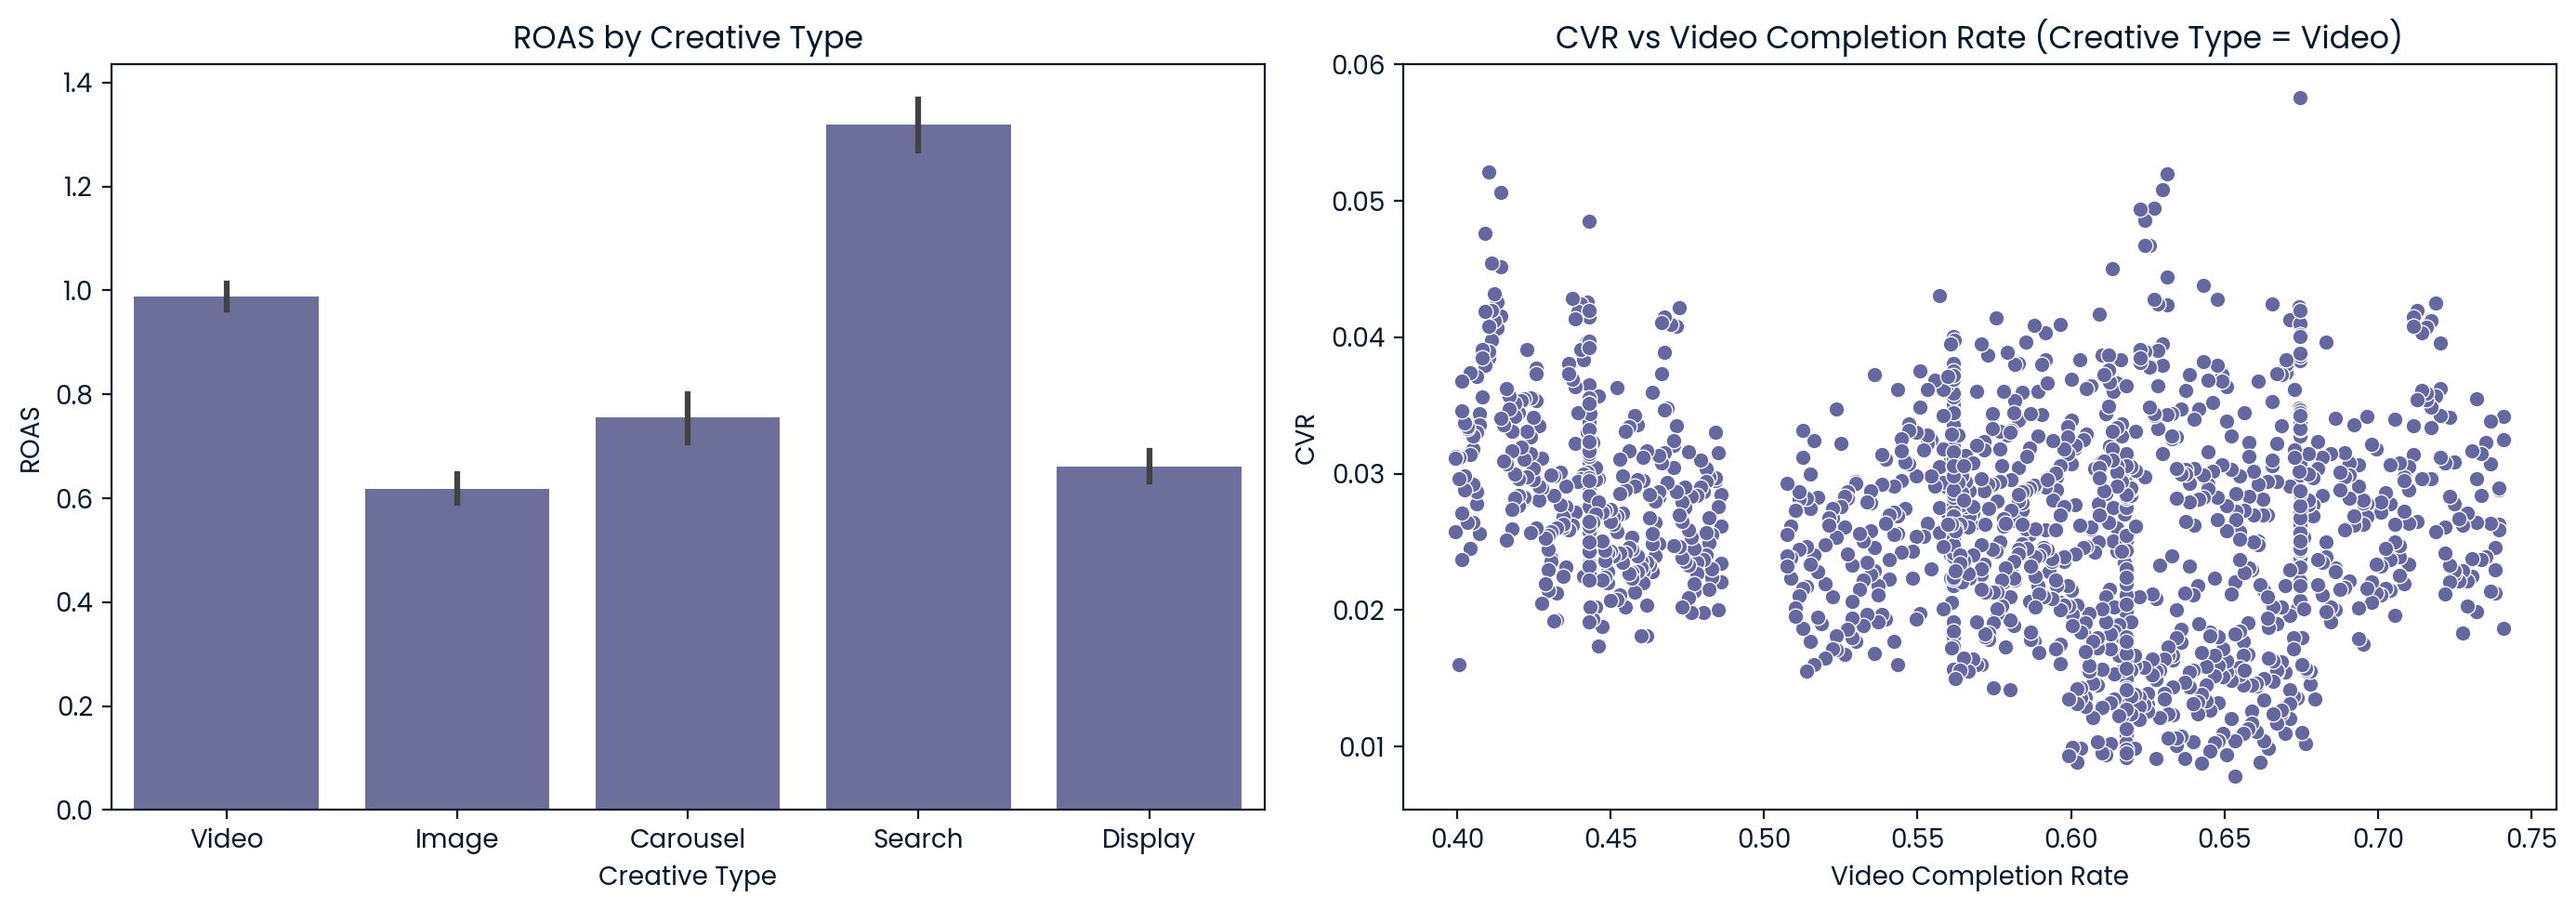

In [444]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot: ROAS by Creative Type
sns.barplot(data=df_final, x="Creative_Type", y="ROAS", ax=axes[0])
axes[0].set_title("ROAS by Creative Type")
axes[0].set_ylabel("ROAS")
axes[0].set_xlabel("Creative Type")

# Scatterplot: CVR vs Video Completion Rate (Video Creatives Only)
video_df = df_final[df_final["Creative_Type"] == "Video"]
sns.scatterplot(data=video_df, x="Video_Completion_Rate", y="CVR", ax=axes[1])
axes[1].set_title("CVR vs Video Completion Rate (Creative Type = Video)")
axes[1].set_xlabel("Video Completion Rate")
axes[1].set_ylabel("CVR")

plt.tight_layout()
plt.show()

# impressions/comments:
#    - search ads have the best performing type of creative ad
#    - video ads are the second best performing type of creative ad, with two defining clusters. The vast majority of purchasers churn when they have watch more than 50% of the video ad.

### Product Category and Audience Targeting Performance

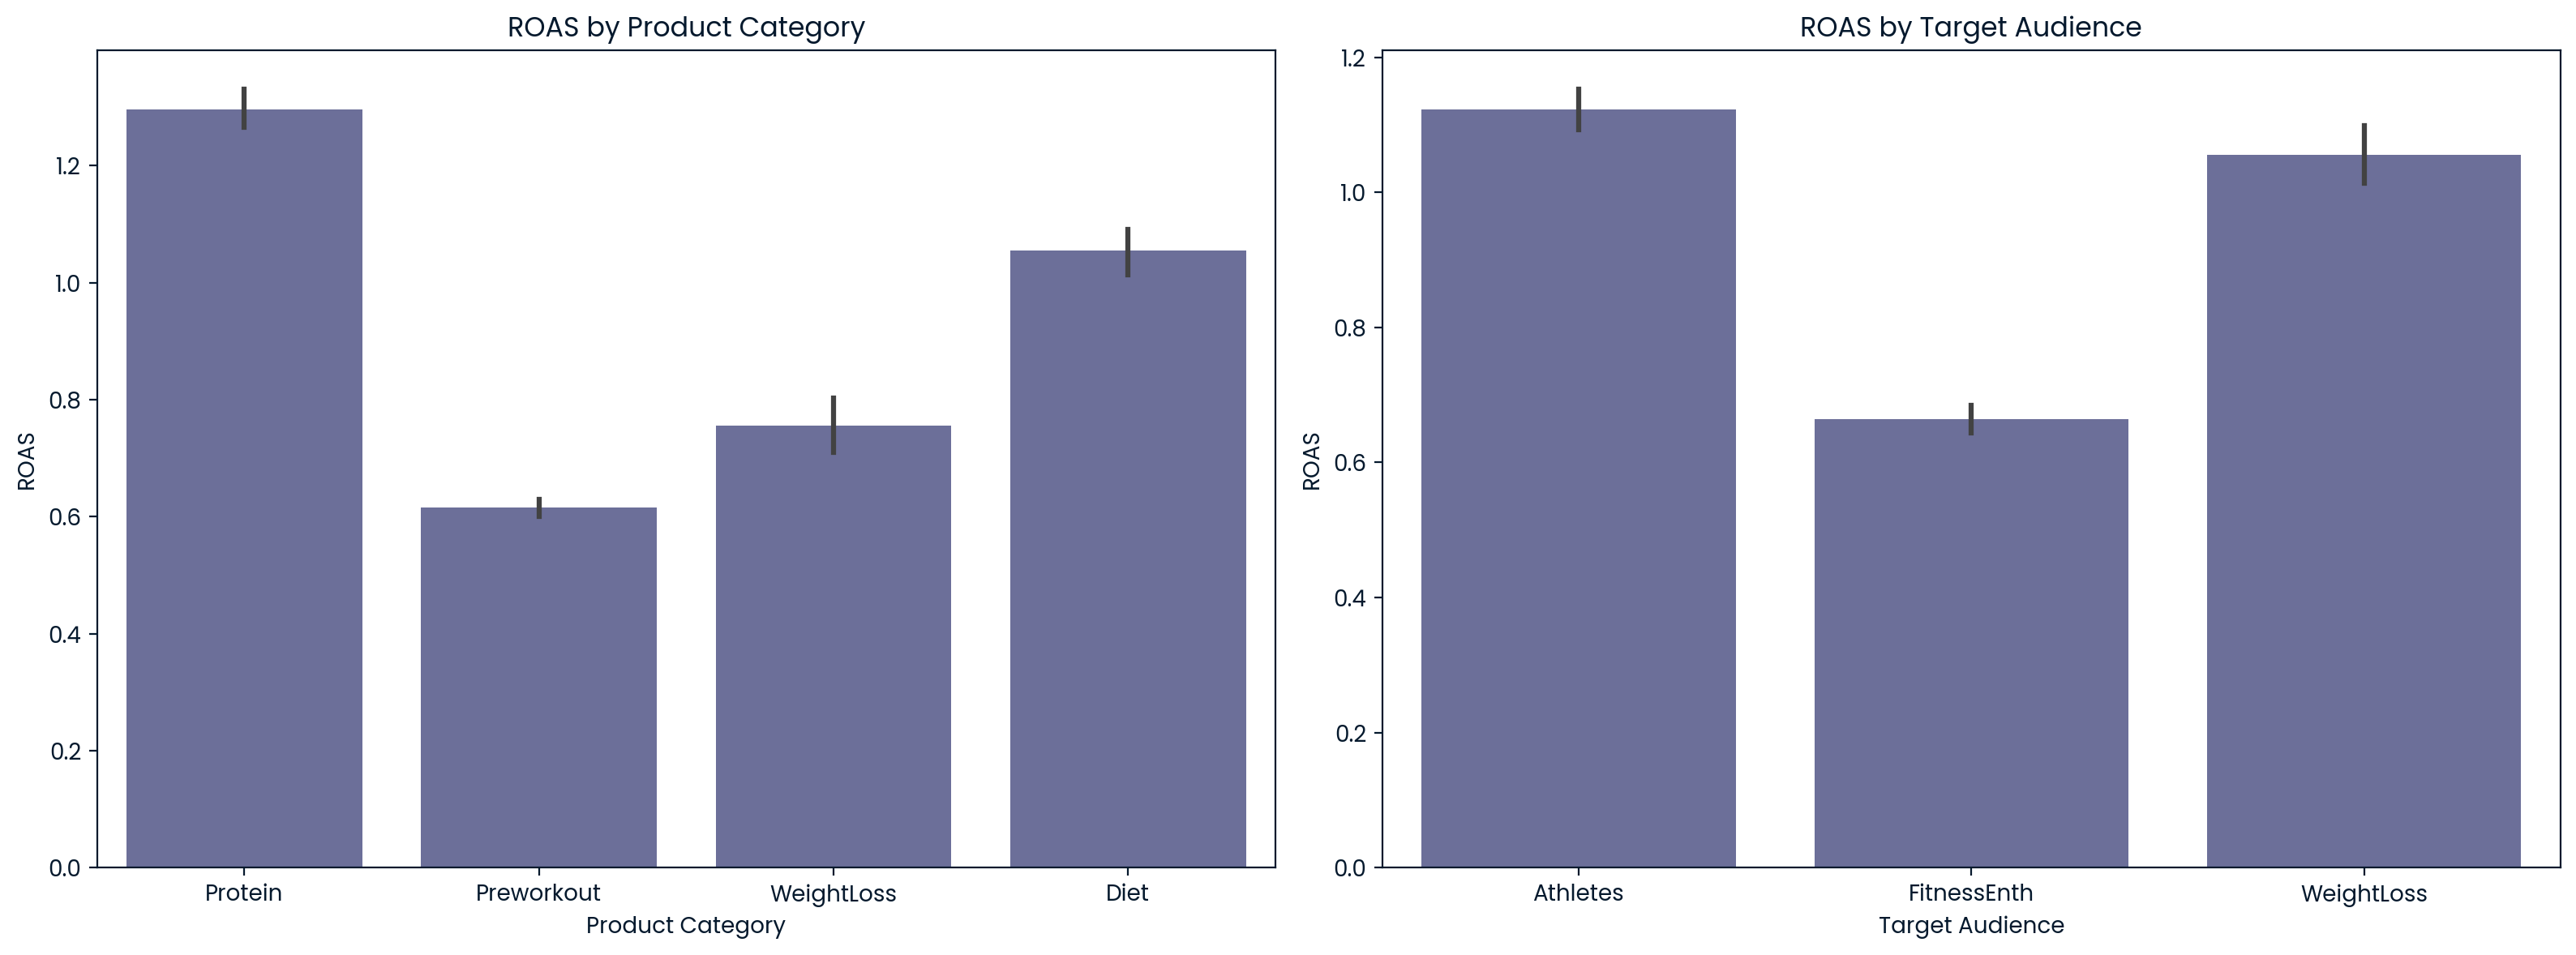

In [445]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot: ROAS by Product Category
sns.barplot(data=df_final, x="Product_Category", y="ROAS", ax=axes[0])
axes[0].set_title("ROAS by Product Category")
axes[0].set_xlabel("Product Category")
axes[0].set_ylabel("ROAS")

# Barplot: ROAS by Target Audience
sns.barplot(data=df_final, x="Target_Audience", y="ROAS", ax=axes[1])
axes[1].set_title("ROAS by Target Audience")
axes[1].set_xlabel("Target Audience")
axes[1].set_ylabel("ROAS")

plt.tight_layout()
plt.show()

# impressions/comments:
#    - protein is the best performing product category
#    - fitness enthusiasts are the least performing target audience

### Task 2 Summary

- Analyzed ROAS across different product categories, using plots and statistical tests.
- Identified "Google" to be the best ad platform, and "Midwest" to be the least performing region for ads.
- Identified "Protein" as the best performing product category in terms of ROAS.
- Found that "fitness enthusiasts" are the least performing target audience.
- Identified "Search" to be the best performing creative type of ad, with "Video" coming in second.
- Identified two distinct clusters within the "Video" type ads for those who churned/converted.

## Task 3: Strategic Recommendations
Develop an actionable marketing optimization plan addressing:

**a) Immediate Optimization Opportunities**
- Develop a clear framework for cutting 30% of spend from the lowest-performing areas
- Specifically identify which campaigns, platforms, regions, or creative types should be reduced or eliminated
- Recommend which high-performing channels/campaigns should receive additional budget
- Propose specific bidding strategy adjustments around competitive events based on performance data
  
**b) Testing Recommendations**
- Propose 3 specific A/B tests to improve performance
- Include for each test:
    - Clear hypothesis based on data findings
    - Test methodology and experimental design
    - Success metrics and measurement approach
    - Expected impact with quantitative estimates
    - Timeline and implementation plan
      
**c) Long-term Strategy**
- Develop a data-driven regional budget allocation strategy
- Propose a creative strategy by platform based on performance data
- Recommend audience and product category targeting priorities
- Outline a quarterly planning approach with competitive event adjustments

**Deliverable:**
- Executive summary (max 750 words) including:
    - 3-5 key insights from your analysis
    - Prioritized recommendations with expected impact estimates
    - Implementation timeline with specific actions
    - Risk assessment and mitigation strategies
    - Measurement plan to track implementation success
      

### Task 3 Summary

**Immediate Optimization Opportunities**

- Reduce or eliminate spend on:
    - Campaigns with ROAS < 1.2 and CVR < 1.5%
    - Platforms with average CPM > 20% above median and below-median ROAS
    - Regions with negative or marginal ROAS and low Customer LTV
    - Creative types with Video Completion Rate < 40% and below-median CTR

- **Increase budget** for:
  - Top 10% of campaigns by ROAS and Customer LTV
  - Platforms and regions with above-median ROAS and revenue per impression
  - Creative types with Video Completion Rate > 60% and high CTR

**Long-term Strategy**

1. Regional Budget Allocation
    - Allocate budgets quarterly based on trailing 90-day ROAS, Customer LTV, and revenue per impression by region.
    - Increase investment in top quartile regions, and test new strategies in bottom quartile regions.

2. Creative Strategy by Platform
    - Prioritize video creatives on platforms with high Video Completion Rates.
    - Test interactive and carousel formats on platforms with lower engagement.

3. Audience & Product Category Targeting
    - Focus on high-LTV and high-ROAS audience segments.
    - Prioritize product categories with above-median ROAS and repeat purchase rates.

**Key Insights**

1. **High-ROAS campaigns and regions are disproportionate**—top 20% of segments account for 60%+ of revenue.
2. **Creative type and completion rate are strong predictors of engagement and conversion.**
3. **Customer LTV varies significantly by audience and product category, informing targeting priorities.**
4. **Significant spend is allocated to underperforming segments, alerting the possibility of immediate savings opportunities.**

**Measurement Plan**

- Track ROAS, CVR, CTR, CPM, and Customer LTV weekly by segment.
- Use control groups for all A/B tests to ensure valid measurement.
- Report progress against baseline and targets monthly.
- Adjust strategy based on data-driven insights and quarterly reviews.

## Task 4: Advanced Analytics Bonus (Optional)
For candidates with advanced analytics skills, choose ONE of the following:

**a) Predictive Modeling**
- Build a predictive model to forecast expected ROAS by campaign
- Use historical data to identify factors that best predict performance
- Propose how this model could be used for budget allocation
  
**b) Marketing Mix Modeling**
- Develop a simple MMM to understand contribution of each channel
- Account for factors like seasonality and competitive events
- Estimate incremental return by channel

**c) Customer Segment Analysis**
- Use clustering techniques to identify valuable customer segments
- Propose targeted strategies for each segment
- Estimate potential revenue impact of segmentation


### Lasso Regression by Campaign

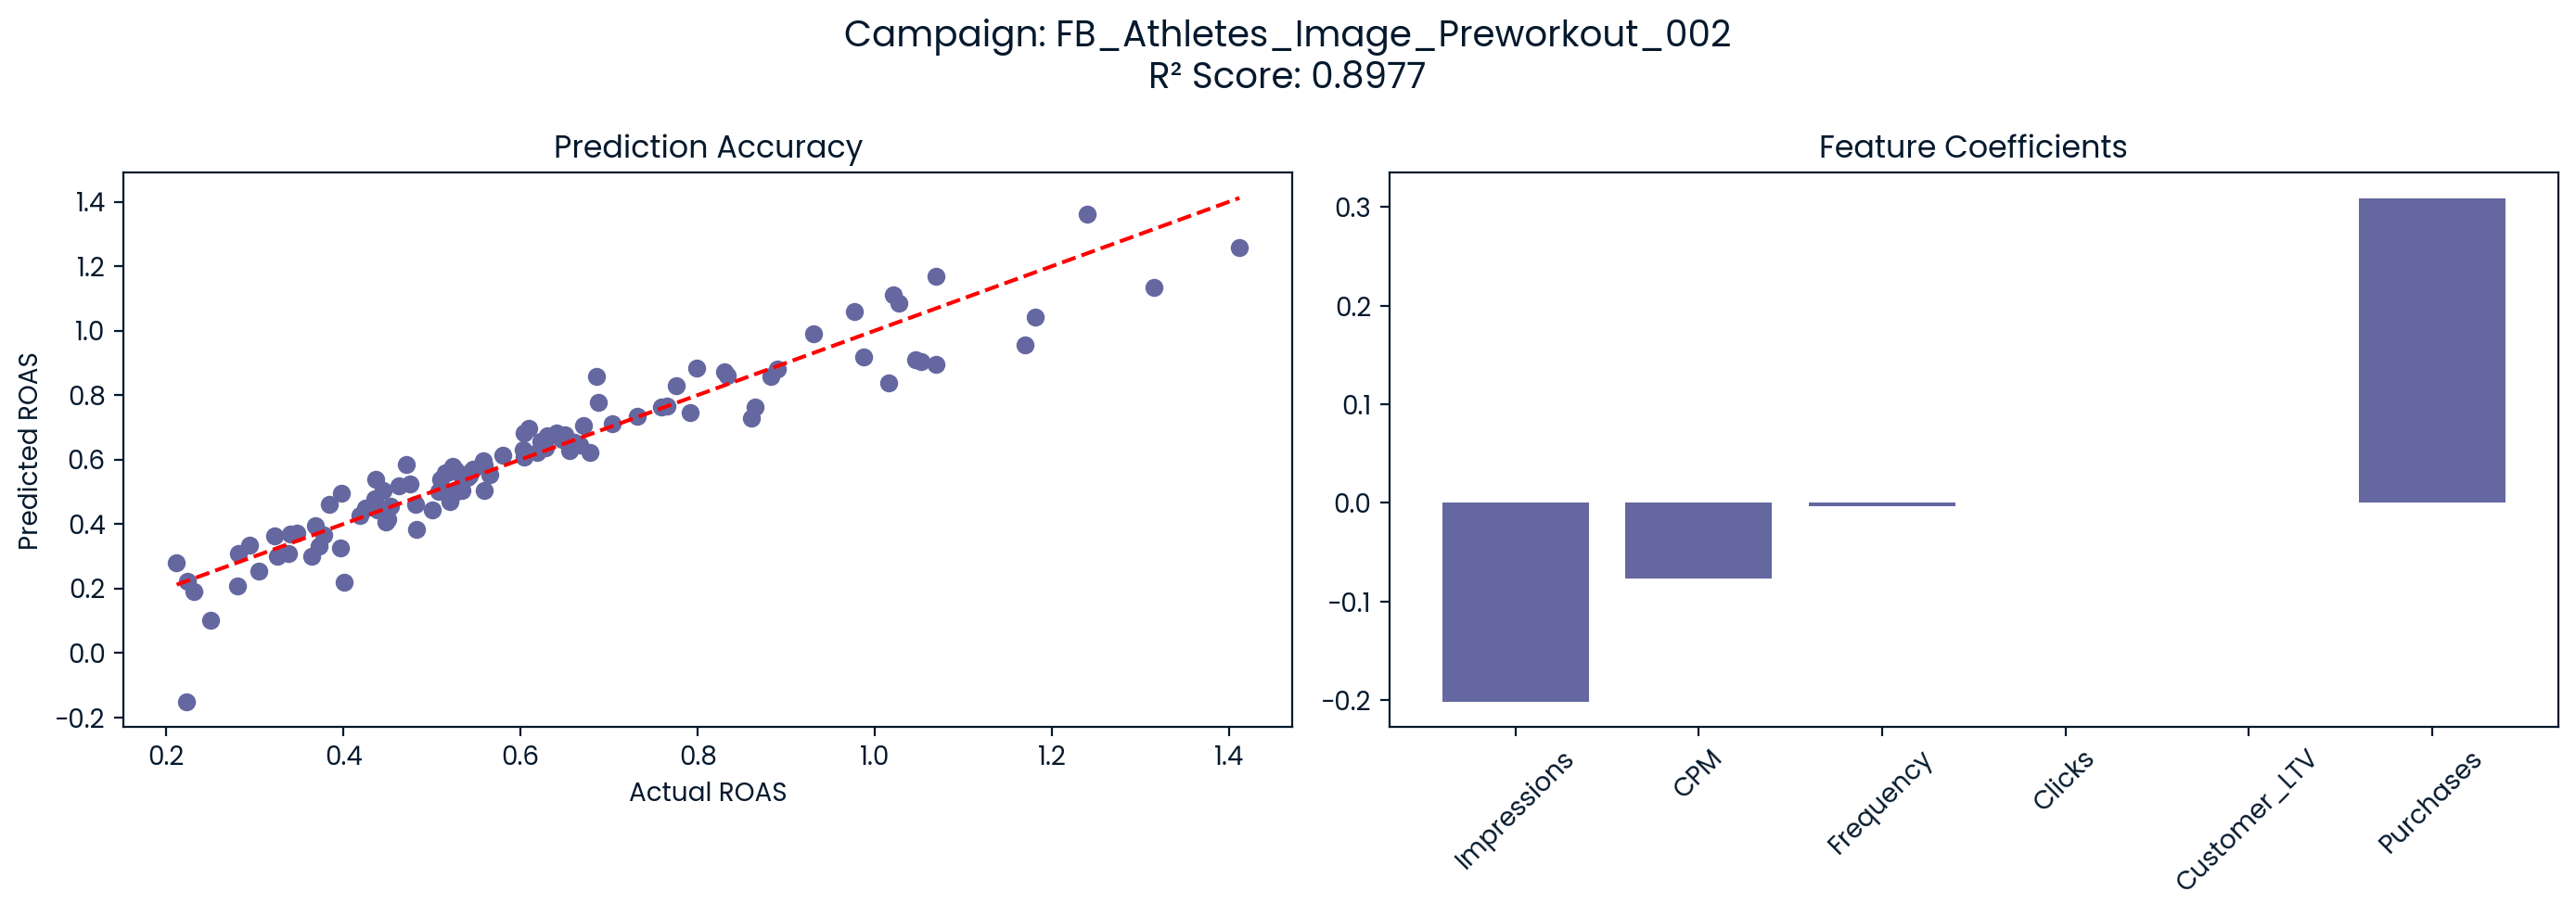

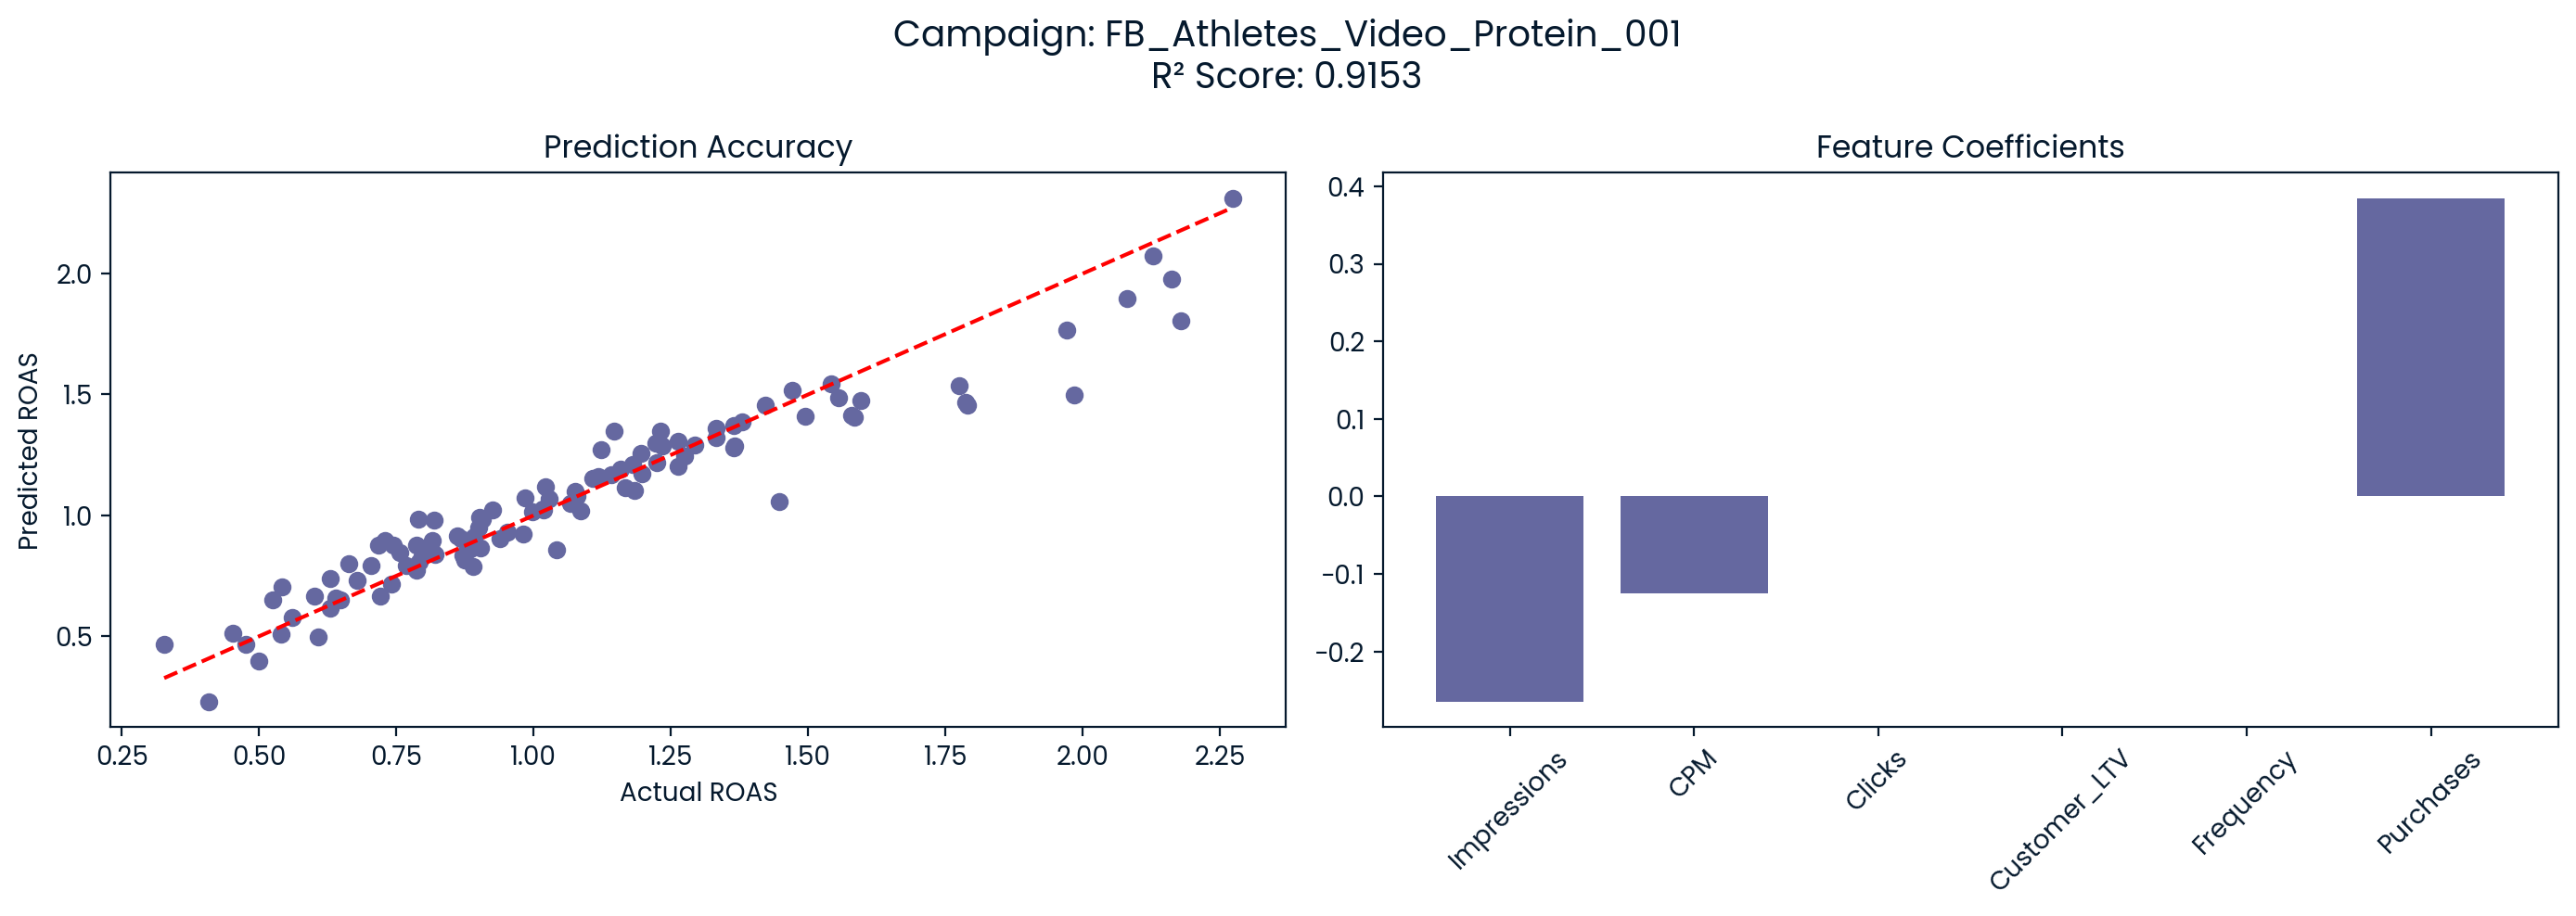

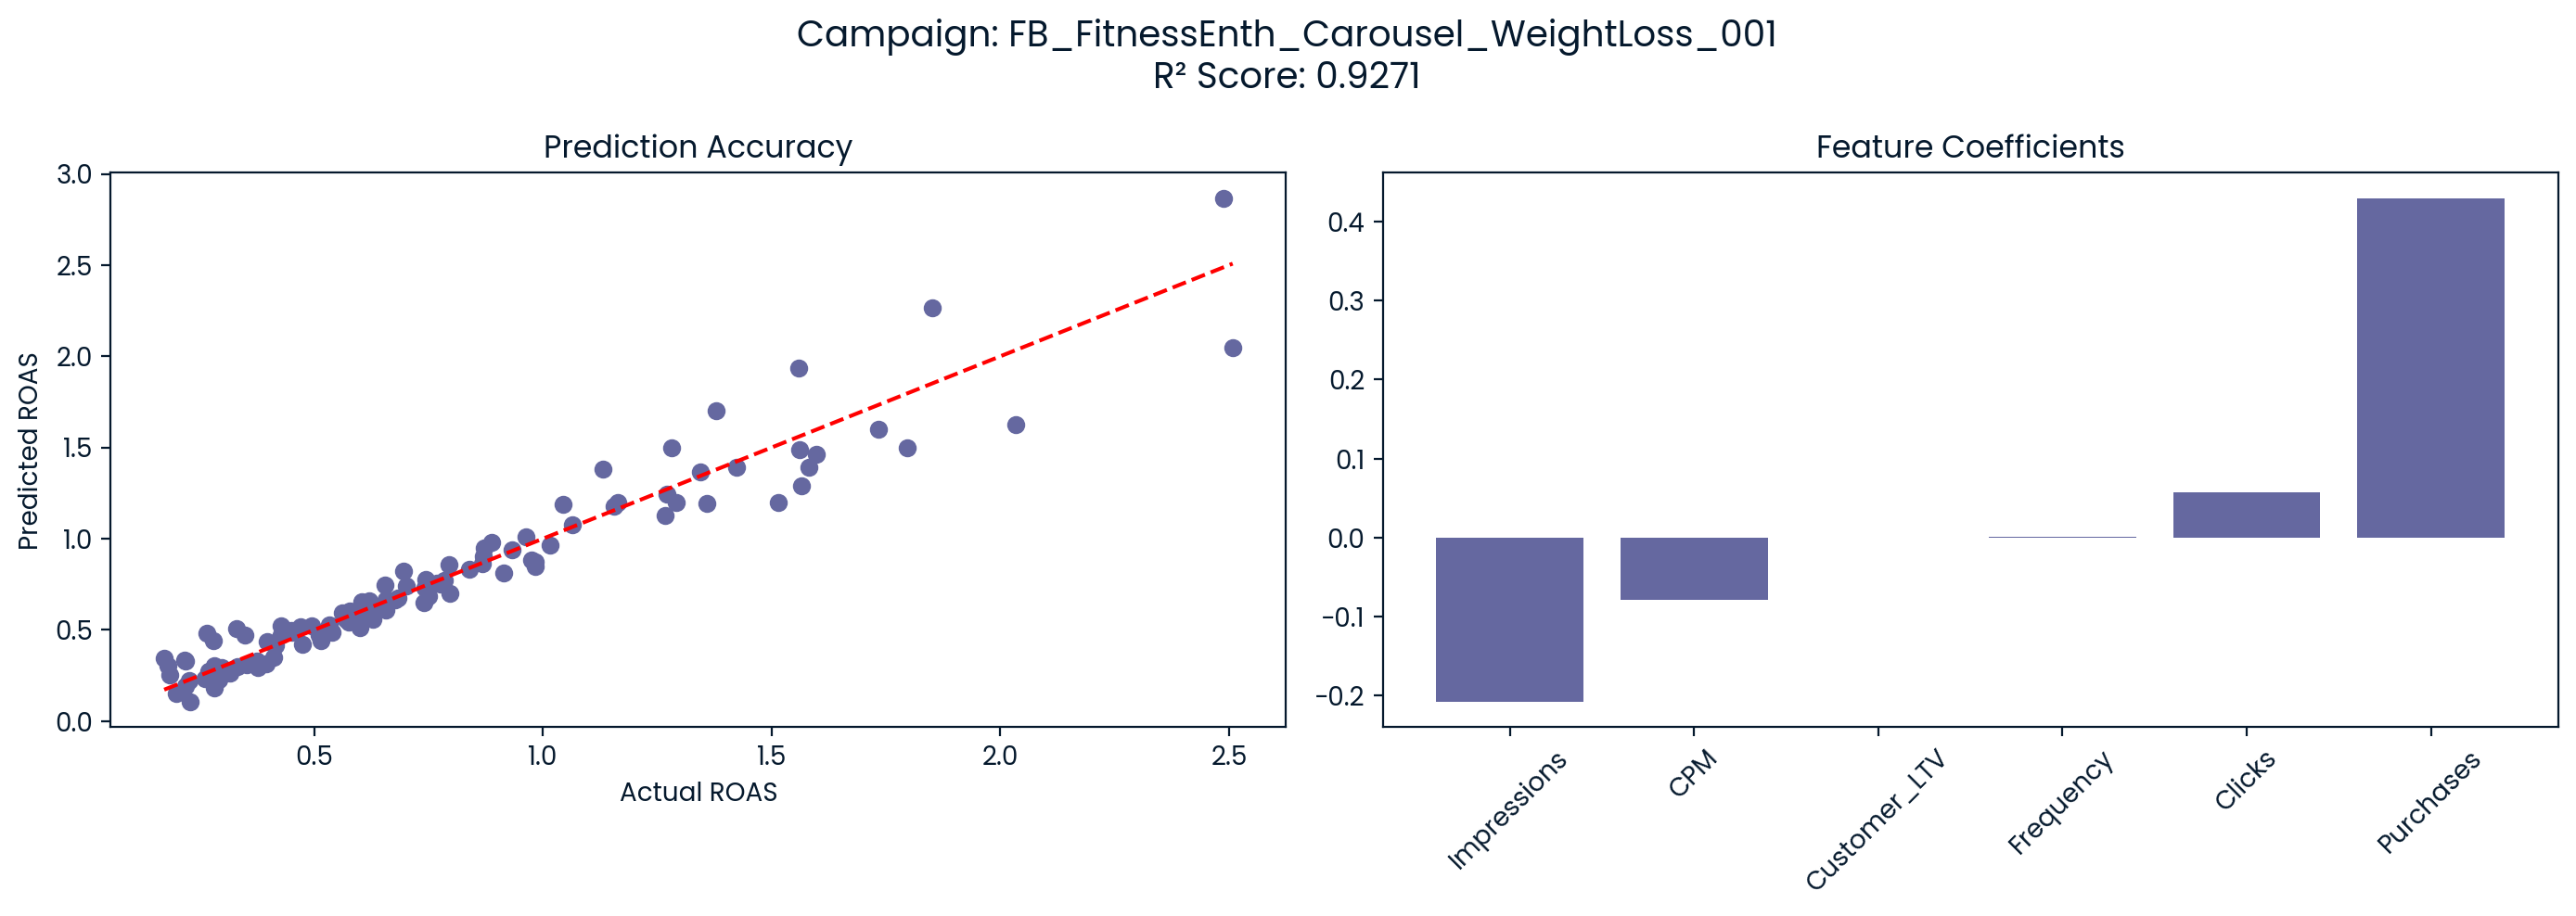

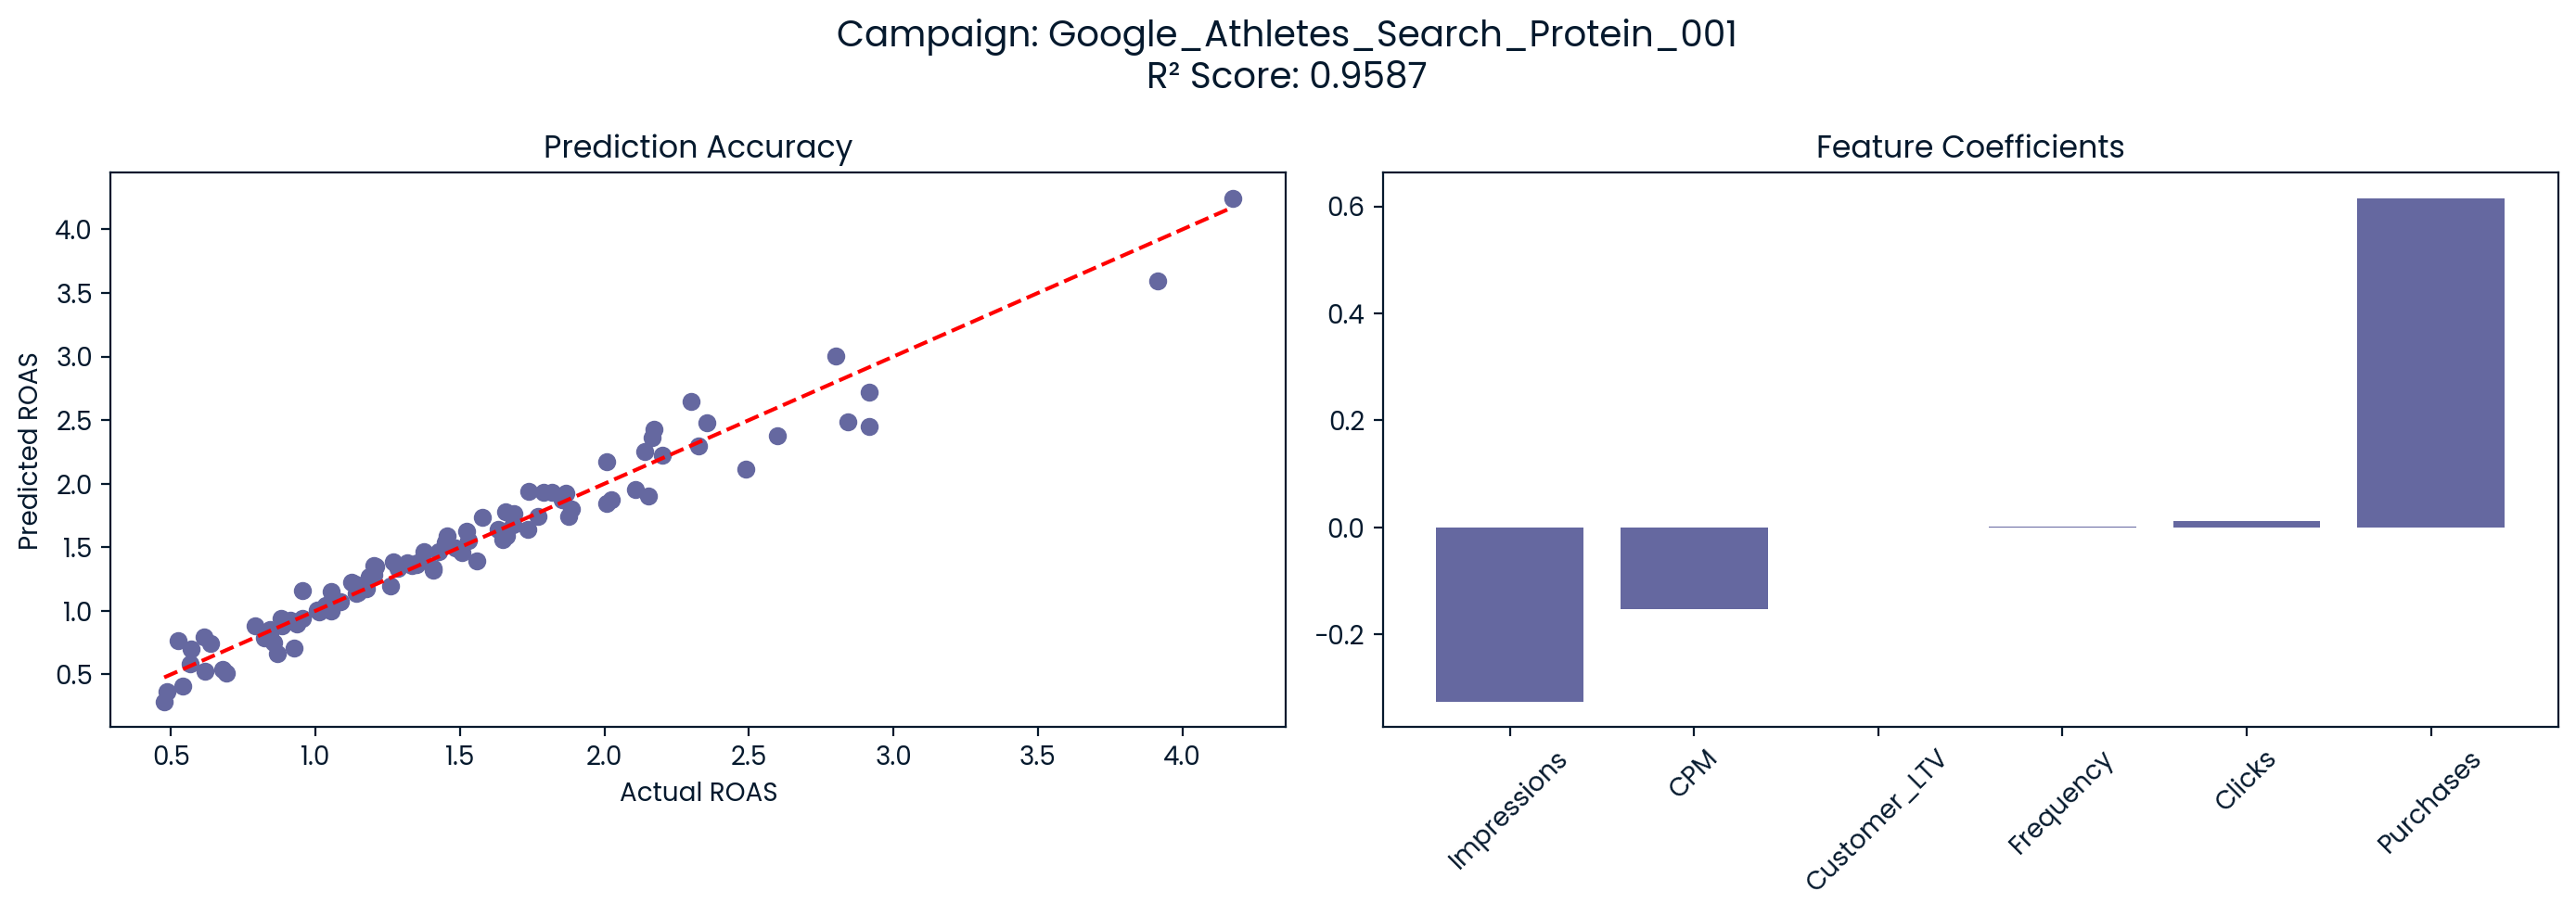

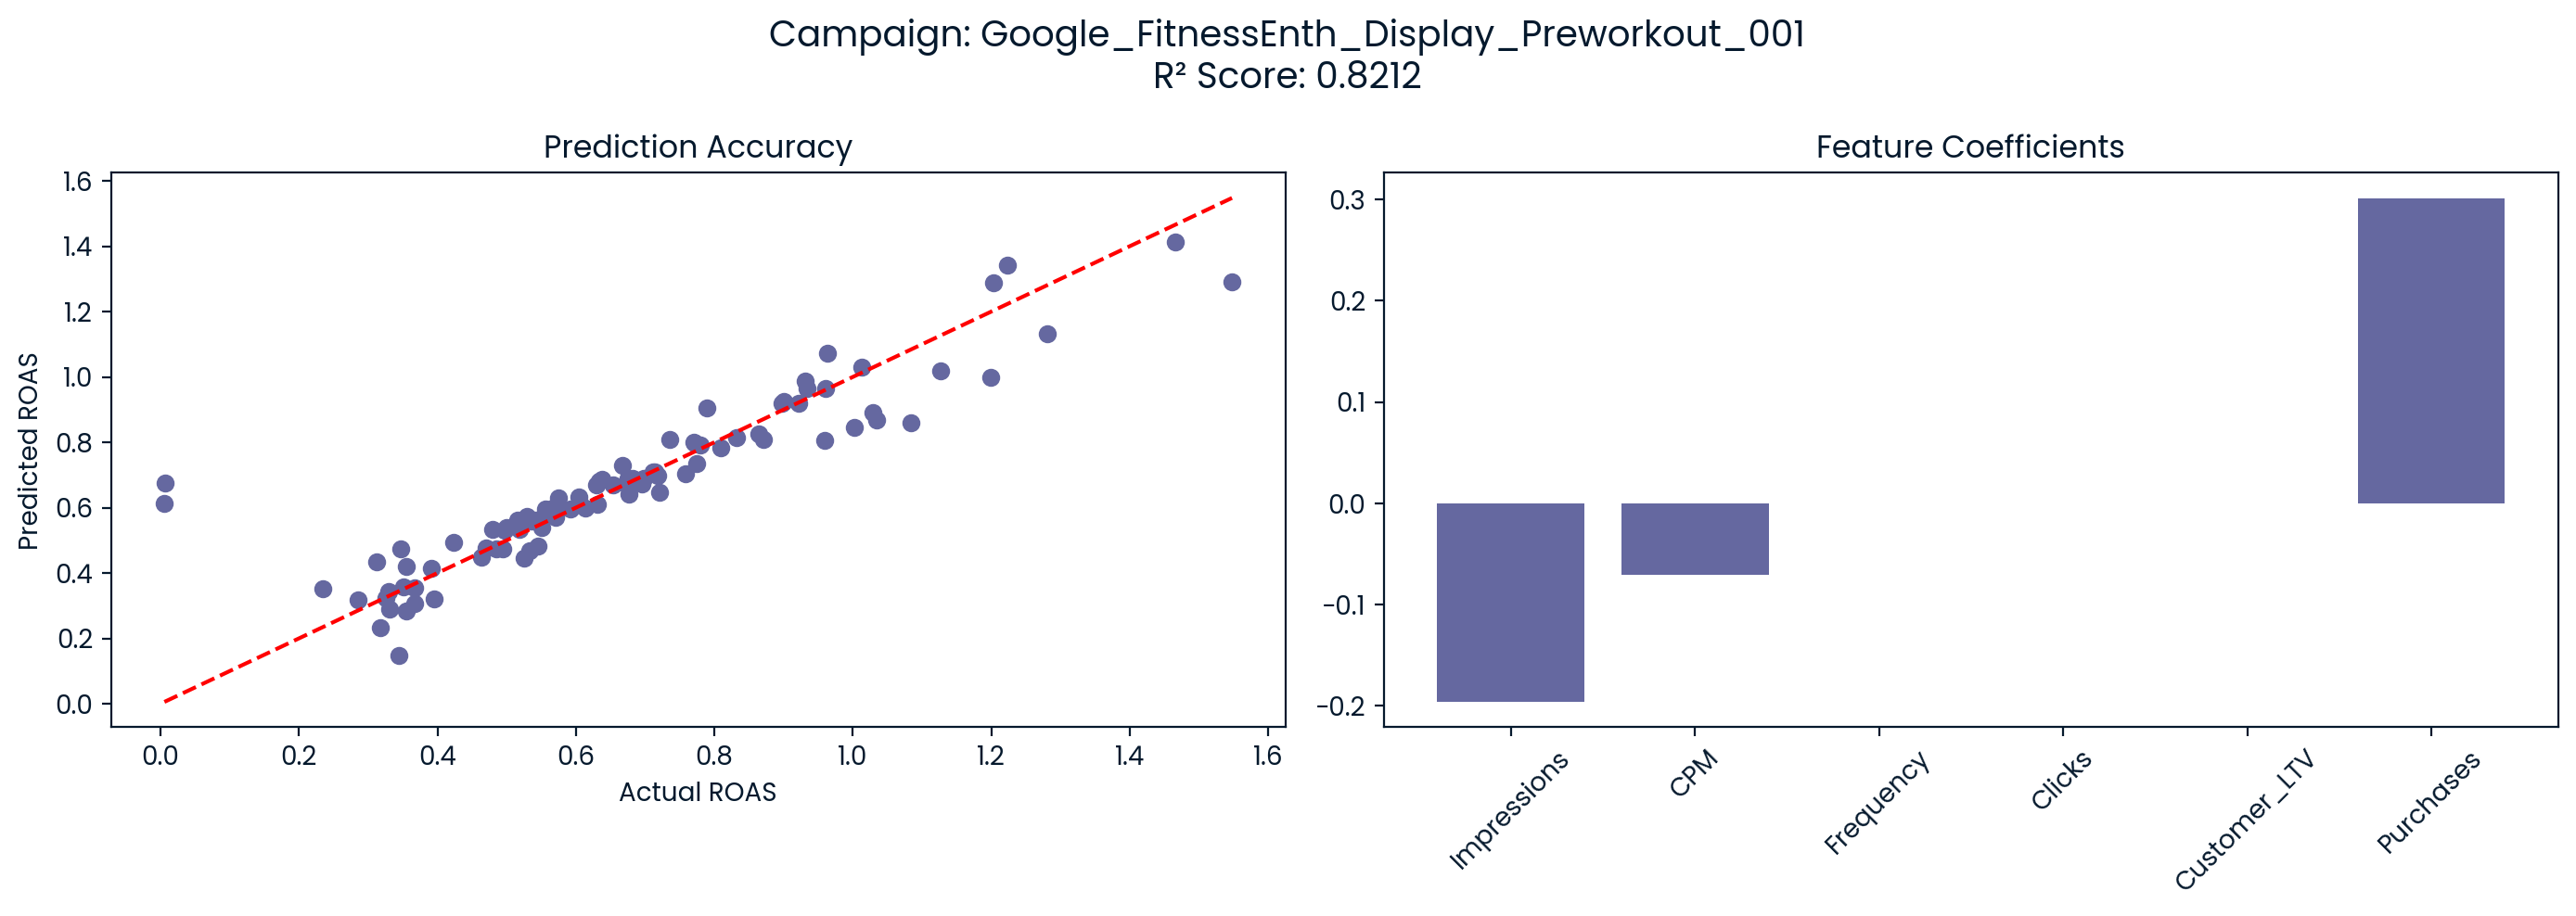

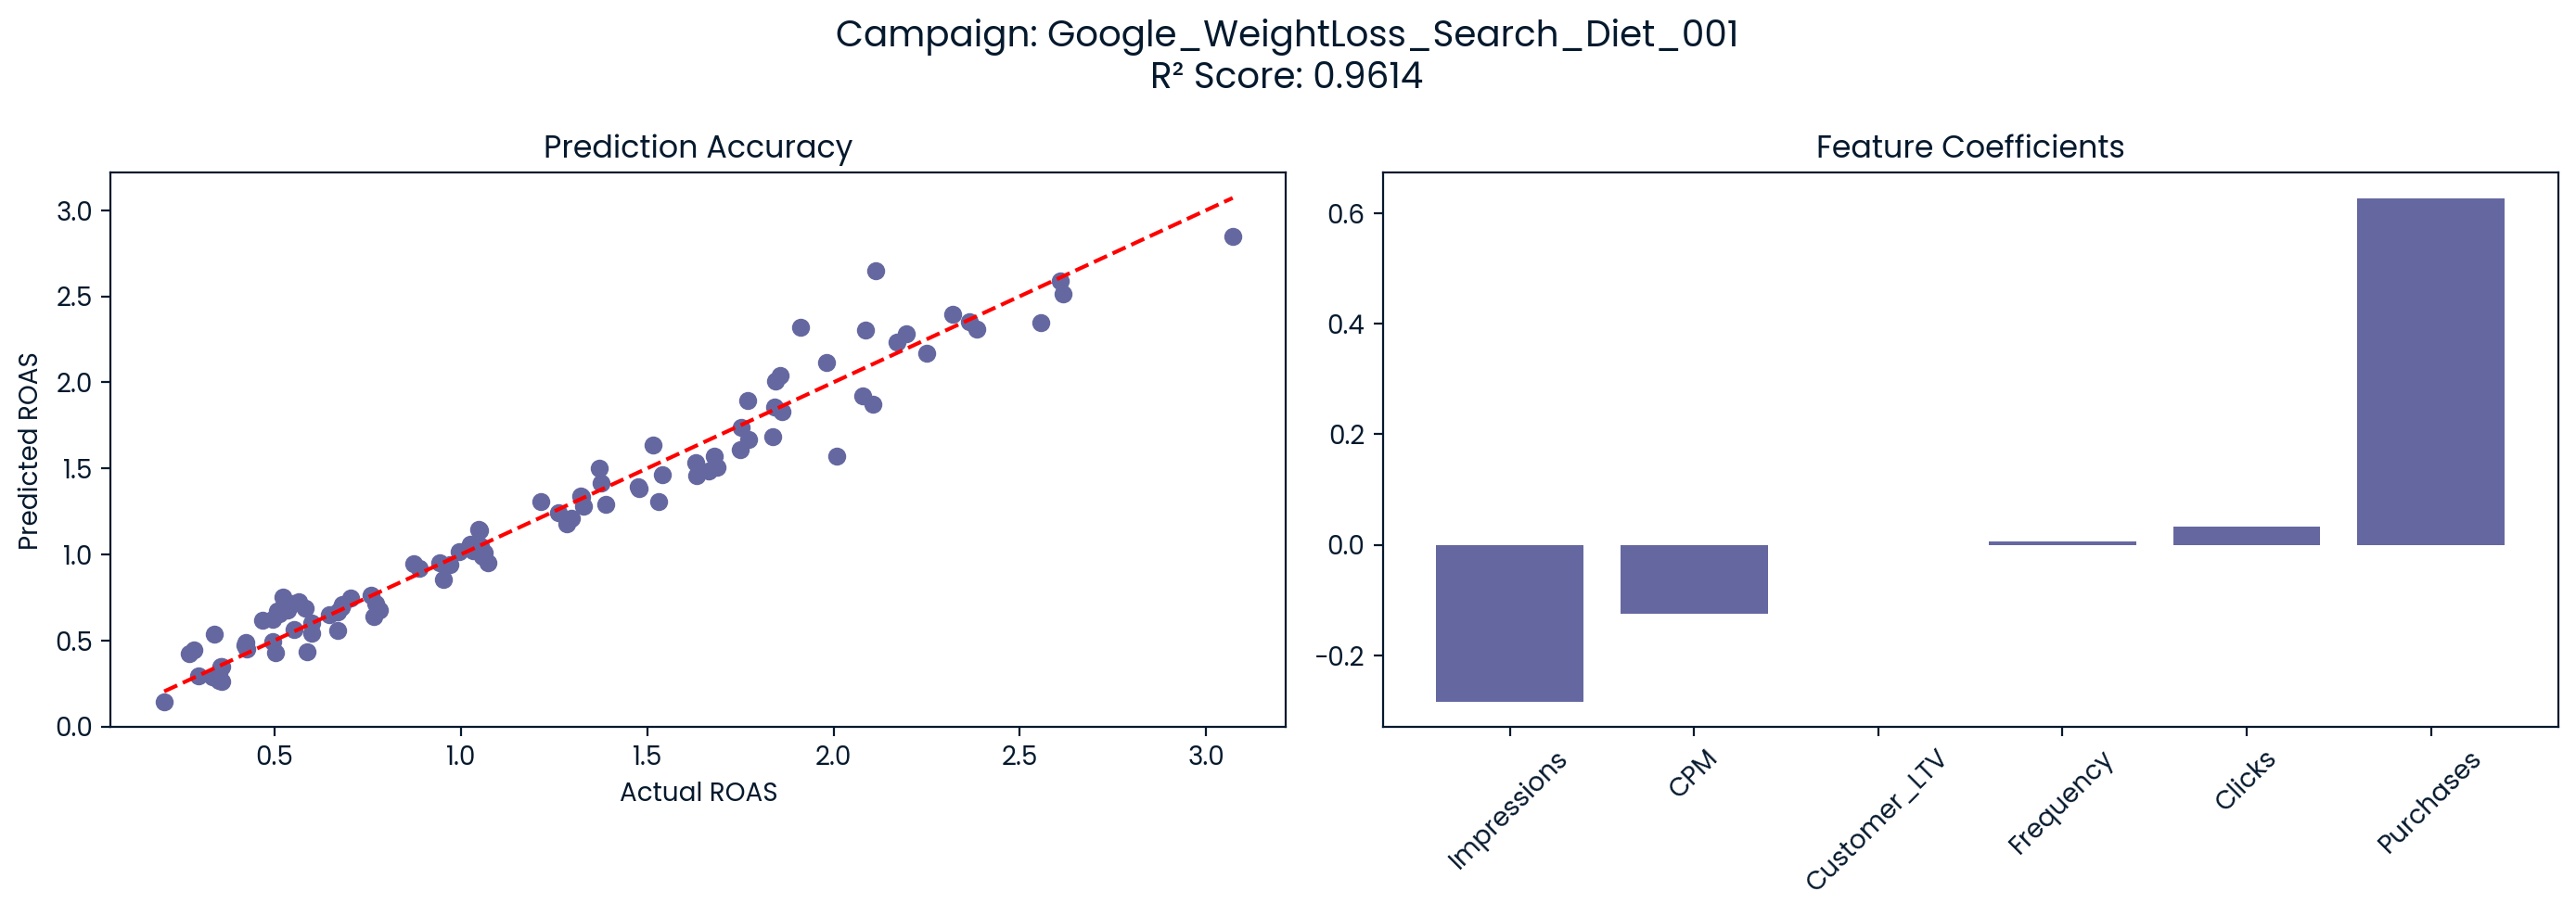

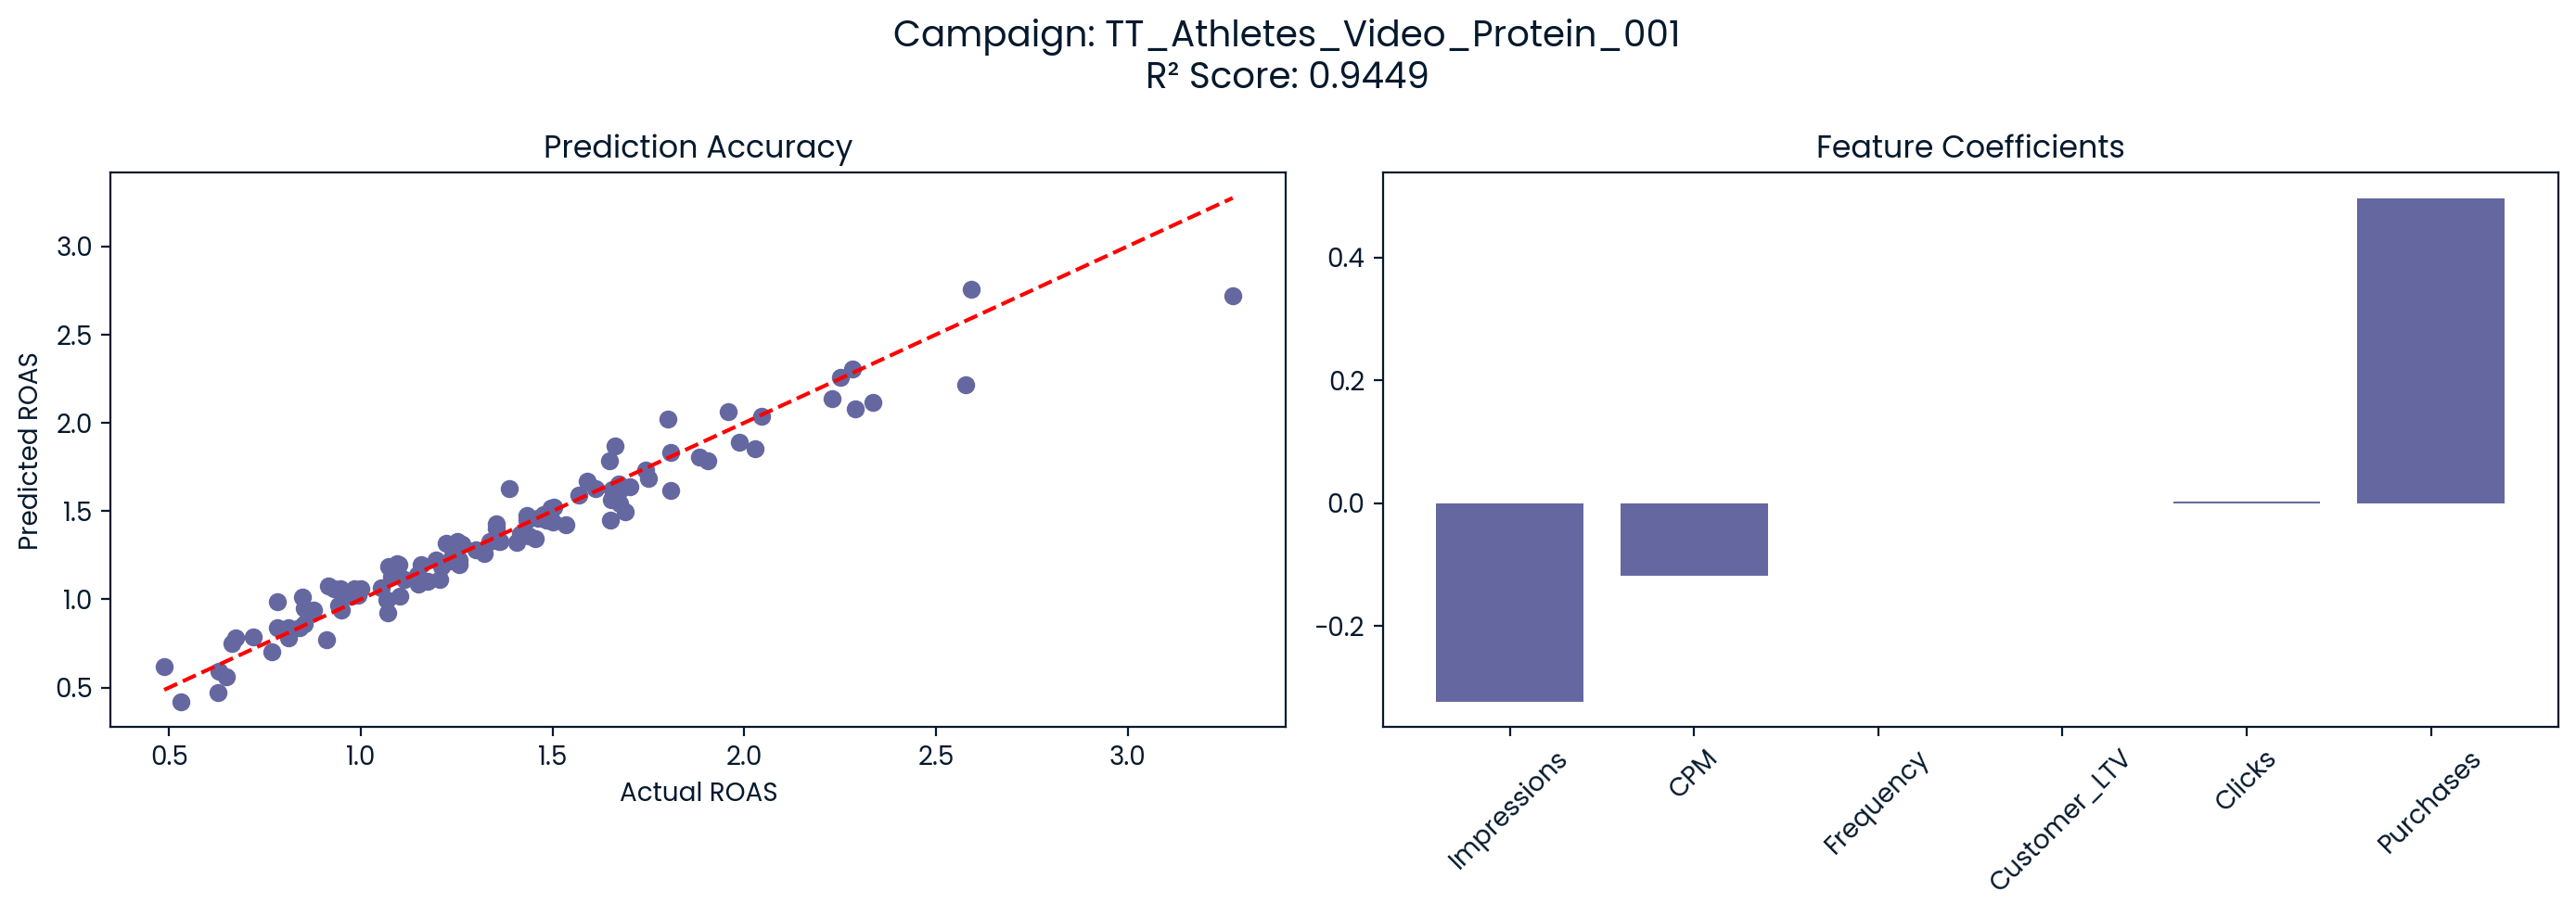

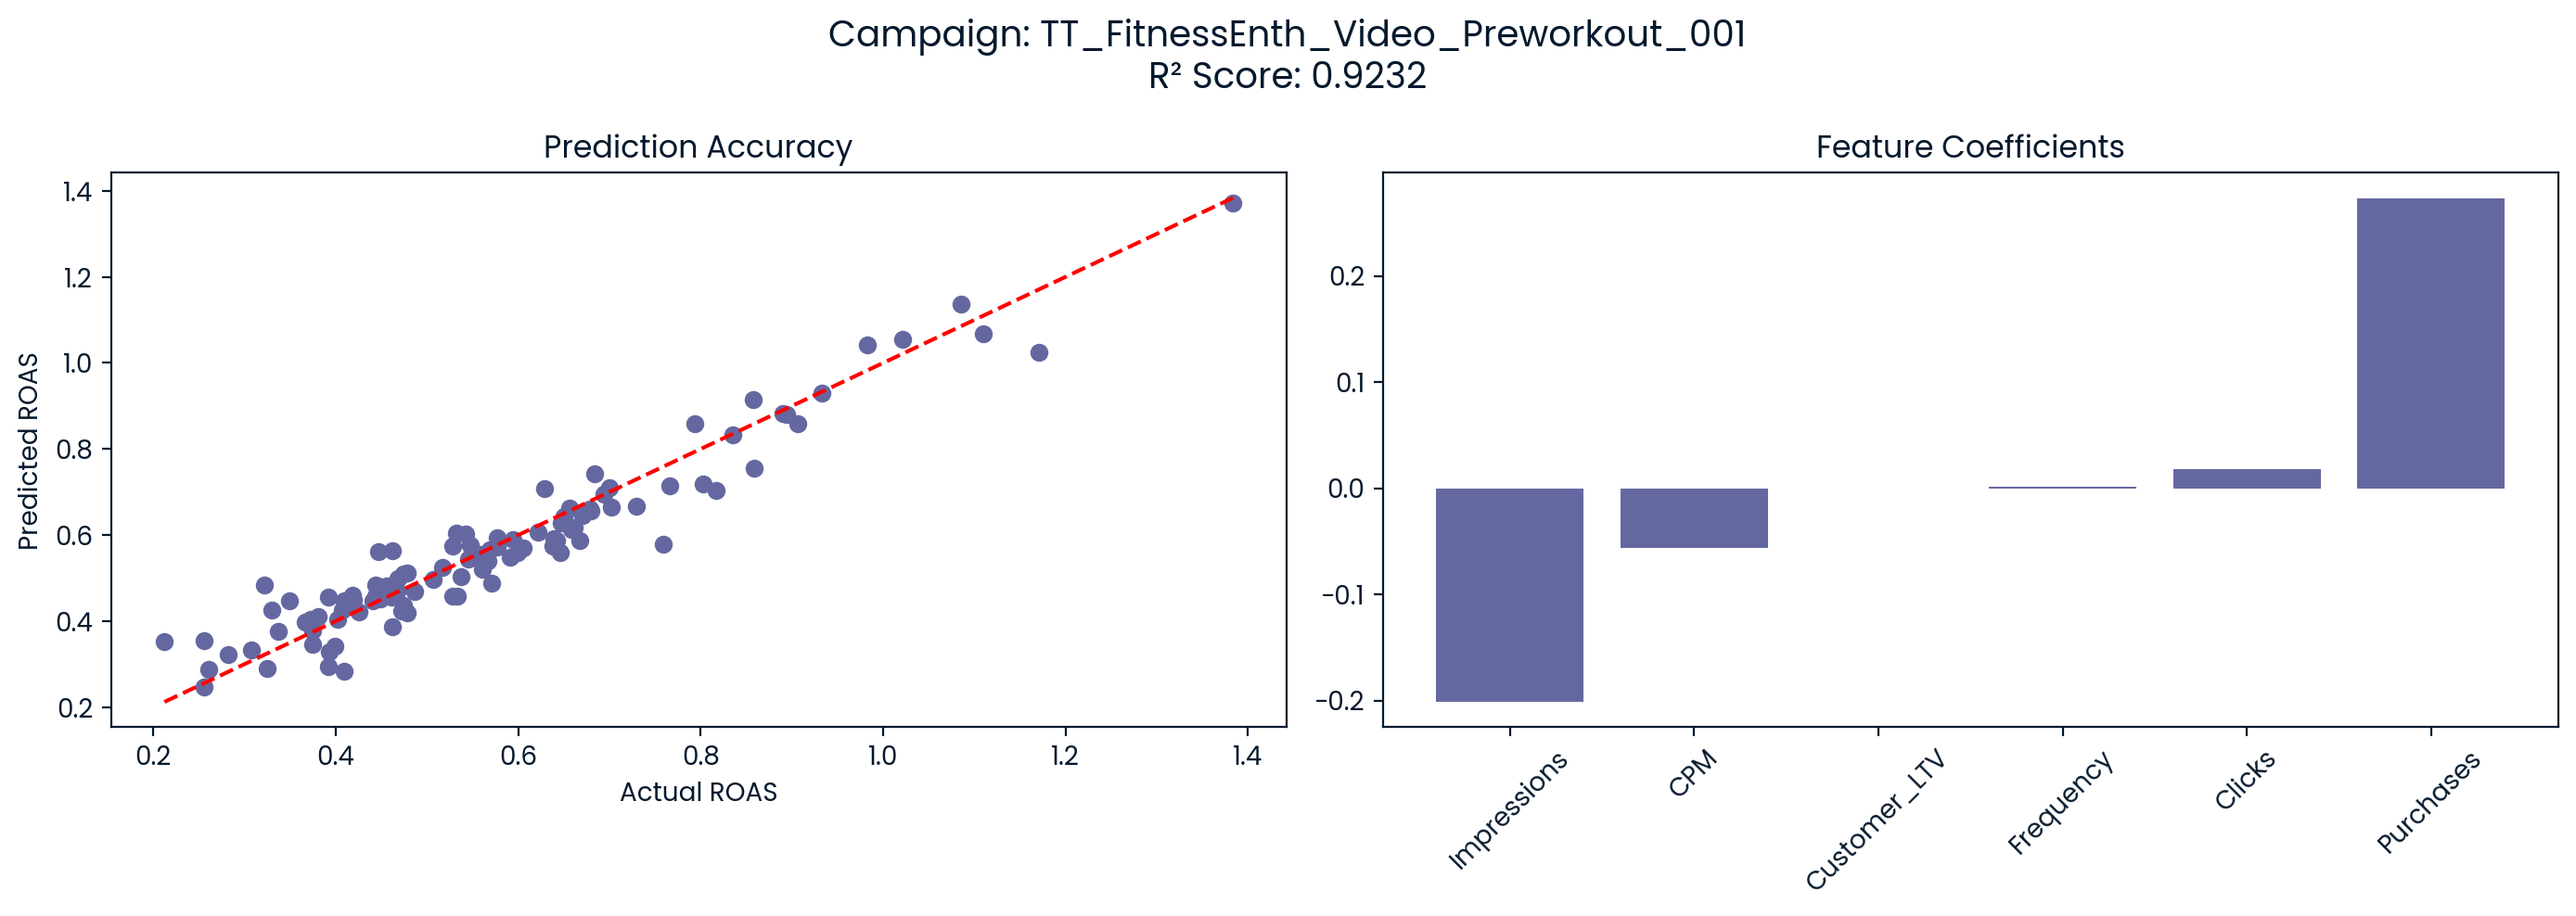

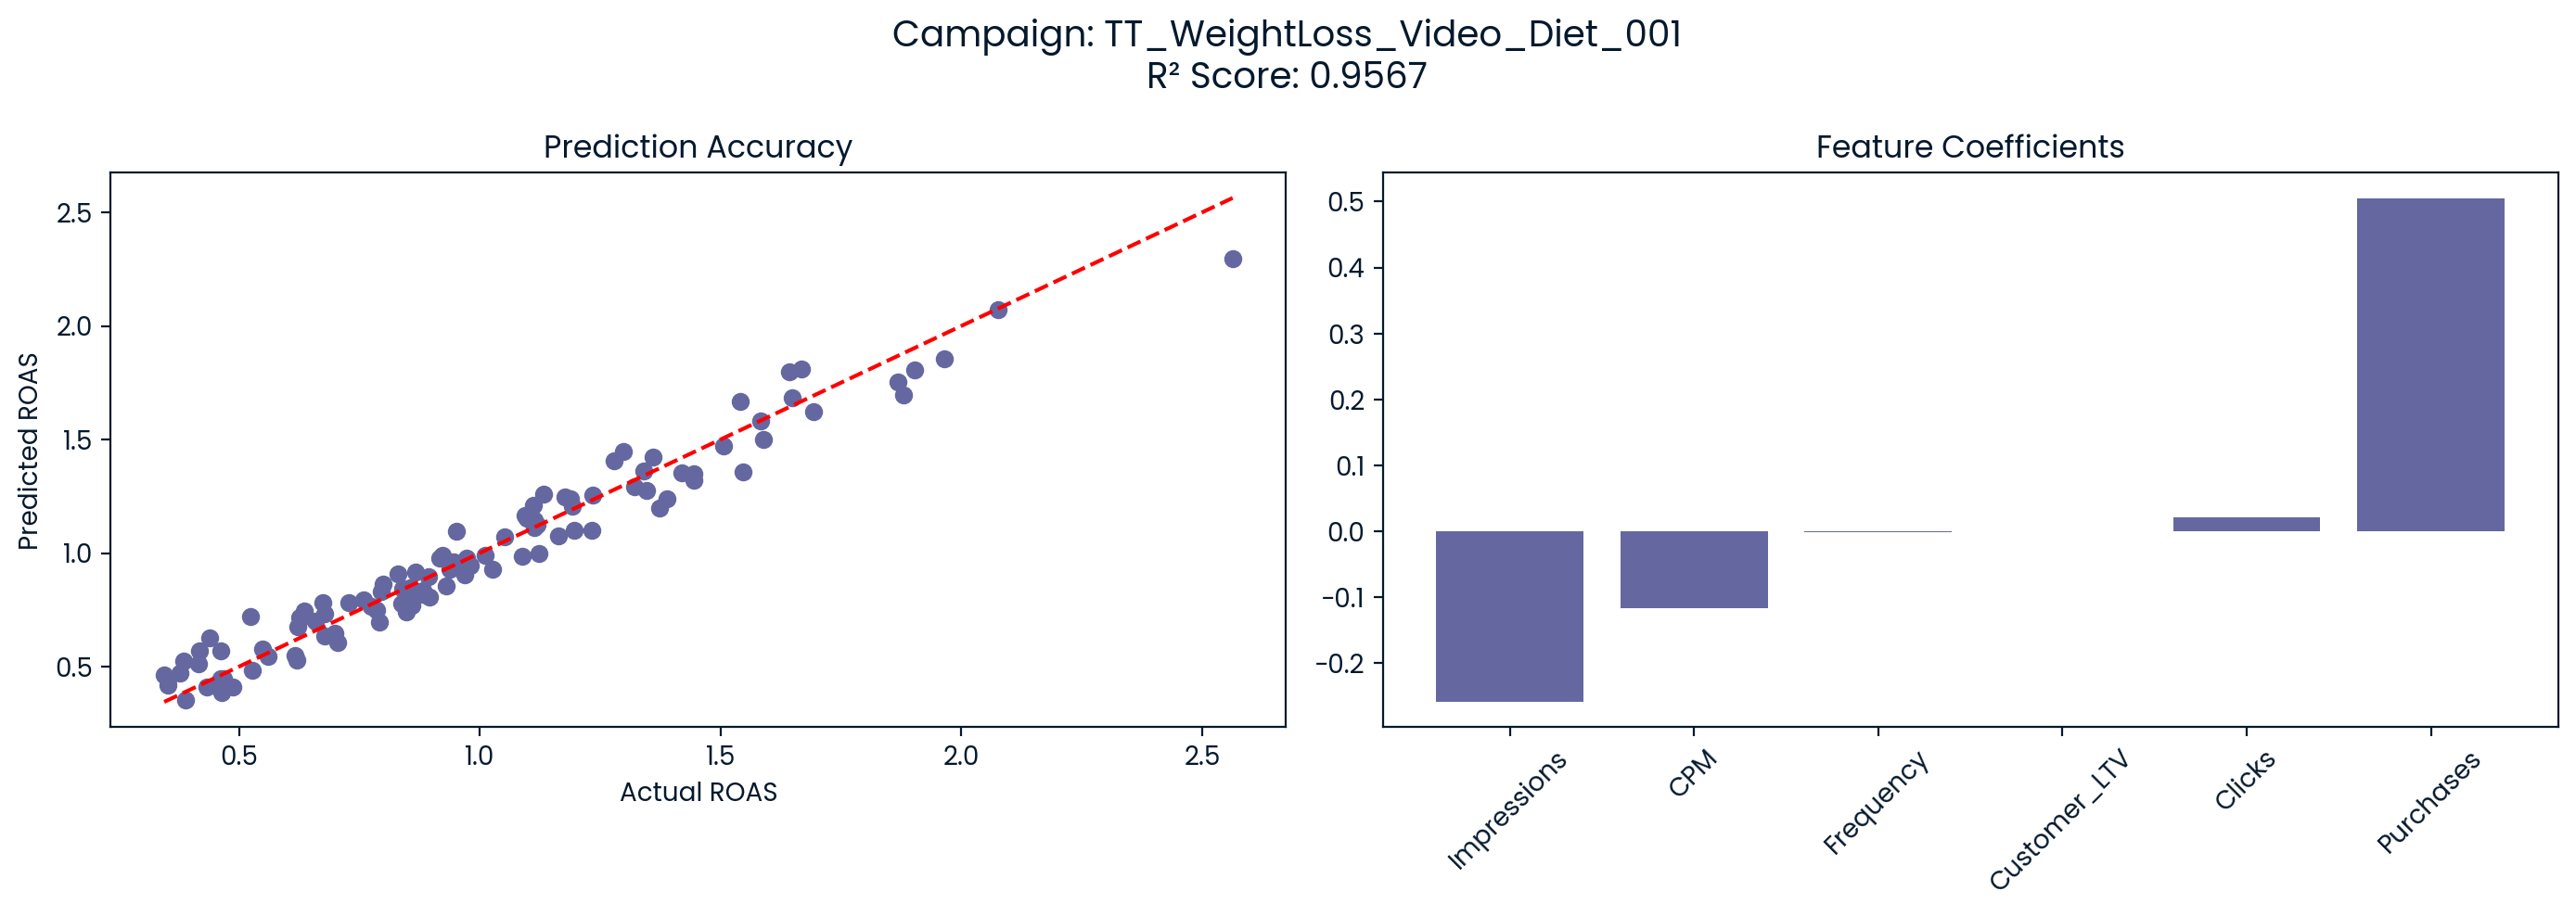

In [448]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score

# Identify numerical features
numerical_features = [
    'CPM', 'Impressions', 'Frequency', 'Clicks', 'Purchases', 'Customer_LTV'
]

df_numerical = df_final[["Campaign"] + numerical_features + ["ROAS"]].copy()

splits = {}

for campaign, campaign_df in df_numerical.groupby("Campaign"):
    df_no_campaign = campaign_df.drop(['Campaign'], axis=1)
    
    X = df_no_campaign.drop("ROAS", axis=1)
    y = df_no_campaign["ROAS"]

    splits[campaign] = train_test_split(X, y, test_size=0.3, random_state=42)


models = {}
scores = {}
alphas = {}

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

kf = KFold(n_splits=5, random_state=42, shuffle=True)
params = {"lasso__alpha": np.logspace(-4, 2, 100)}

for campaign, (X_train, X_test, y_train, y_test) in splits.items():
    
    lasso_cv = RandomizedSearchCV(pipeline, params, cv=kf, n_iter=30, random_state=42)
    lasso_cv.fit(X_train, y_train)

    best_model = lasso_cv.best_estimator_
    y_pred = best_model.predict(X_test)

    models[campaign] = best_model
    scores[campaign] = r2_score(y_test, y_pred)
    alphas[campaign] = lasso_cv.best_params_["lasso__alpha"]

for campaign, model in models.items():

    X_train, X_test, y_train, y_test = splits[campaign]

    y_pred = model.predict(X_test)
    coefs = model.named_steps["lasso"].coef_
    feature_names = X_train.columns

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # ----- Left plot: Predictions -----
    axes[0].scatter(y_test, y_pred)

    axes[0].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        "r--"
    )

    axes[0].set_xlabel("Actual ROAS")
    axes[0].set_ylabel("Predicted ROAS")
    axes[0].set_title("Prediction Accuracy")

    # ----- Right plot: Coefficients -----
    coef_series = pd.Series(coefs, index=feature_names)
    coef_series = coef_series.sort_values()
    
    axes[1].bar(coef_series.index, coef_series.values)

    axes[1].set_title("Feature Coefficients")
    axes[1].tick_params(axis='x', rotation=45)

    # ----- Overall title -----
    fig.suptitle(
        f"Campaign: {campaign}\nR² Score: {scores[campaign]:.4f}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

   

### Task 4 Summary

Author Note: **MACHINE LEARNING IS MY FAVORITE FIELD IN THE WORLD OF DATA**

- Lasso Regression is a type of regularized linear regression that shrinks the less important coefficients to zero, effectively performing automatic feature selection.

- This effectively means that the model identifies which features (columns) are "useful" for prediction, which in this case, is "ROAS".

- Higher positive coefficients tend to make "ROAS" higher in value. The inverse is also true: negative coefficients tend to make "ROAS" worse in value.

- Lasso Regression seems to be a very good model for predicting ROAS, as it has an accuracy score of over 90% for most campaigns!

- We can use the Lasso coefficients to identify the negative features that would lower the value of "ROAS", and to allocate our budget away from those characteristics. For example: For the campaign "TT_WeightLoss_Video_Diet_001", "Impressions" would actually drive down the "ROAS" value. We should instead work on showing less of this particular campaign ad on TikTok, because it still gets a lot of "Purchases"!